In [1]:
import stan
import pandas as pd

import nest_asyncio
nest_asyncio.apply()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import optimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.stats import nbinom
from scipy.stats import norm
import arviz as az

%matplotlib inline

# Load in and clean data

In [3]:
data = pd.read_pickle('oxcgrt_data.pkl')

In [4]:
states = pd.unique(data['RegionName'])[1:]
pops = pd.read_csv('https://gist.githubusercontent.com/bradoyler/0fd473541083cfa9ea6b5da57b08461c/raw/fa5f59ff1ce7ad9ff792e223b9ac05c564b7c0fe/us-state-populations.csv')

In [5]:
data.head()

,RegionName,Date,School closure,Workplace closure,Cancel public events,Restrictions on gatherings,Public transport closure,Stay at home requirements,Restrictions on internal movement,International travel controls,...,StringencyIndex,StringencyIndexForDisplay,StringencyLegacyIndex,StringencyLegacyIndexForDisplay,GovernmentResponseIndex,GovernmentResponseIndexForDisplay,ContainmentHealthIndex,ContainmentHealthIndexForDisplay,EconomicSupportIndex,EconomicSupportIndexForDisplay
255624,NaN,20200101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255625,NaN,20200102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255626,NaN,20200103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255627,NaN,20200104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255628,NaN,20200105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
data.columns

Index(['RegionName', 'Date', 'School closure', 'Workplace closure',
       'Cancel public events', 'Restrictions on gatherings',
       'Public transport closure', 'Stay at home requirements',
       'Restrictions on internal movement', 'International travel controls',
       'Public information campaigns', 'Testing policy', 'Contact tracing',
       'Facial coverings', 'Protection of elderly people', 'ConfirmedCases',
       'ConfirmedDeaths', 'StringencyIndex', 'StringencyIndexForDisplay',
       'StringencyLegacyIndex', 'StringencyLegacyIndexForDisplay',
       'GovernmentResponseIndex', 'GovernmentResponseIndexForDisplay',
       'ContainmentHealthIndex', 'ContainmentHealthIndexForDisplay',
       'EconomicSupportIndex', 'EconomicSupportIndexForDisplay'],
      dtype='object')

In [7]:
pops.head()

,code,state,pop_2014
0,AL,Alabama,4849377
1,AK,Alaska,736732
2,AZ,Arizona,6731484
3,AR,Arkansas,2966369
4,CA,California,38802500


In [8]:
def get_state_data(data,state):#,tf):
    state_data = data[data['RegionName']==state]
    #state_data = state_data[0:tf,:]
    return state_data

def get_state_pop(pops, state):
    state_tmp = state
    if state == 'Washington DC':
        state_tmp = 'District of Columbia'
        
    N = pops[pops['state']==state_tmp]['pop_2014']
    N = np.array(N).astype('float')
    return N

def clean_npis(state_data,tf,inds):
    u = state_data[['School closure',
                   'Workplace closure',
                   'Cancel public events',
                   'Restrictions on gatherings',
                   'Public transport closure',
                   'Stay at home requirements',
                   'Restrictions on internal movement',
                   'International travel controls',
                   'Public information campaigns',
                   'Testing policy',
                   'Contact tracing',
                   'Facial coverings',
                   'Protection of elderly people']]#,
                   #'Date']]
    u = np.array(u)[0:tf,inds].astype(float);
    # u = np.array(state_data)[0:tf,[6,8,10,12,14,16,18,20,26,28,30,32]].astype(float);
    # remove int'l travel controls [20]
    #u = np.array(state_data)[0:tf,[6,8,10,12,14,16,18,26,28,30,32]].astype(float);
    p = np.shape(u)[1]
    
    # set NaN values to last number previously recorded
    for j in range(tf):
        # determine columns with NaN values
        nancols = np.isnan(u[j,:])
        if j == 0:
            # on day 0, change any NaN to 0, meaning that no policies are enacted
            u[j,np.isnan(u[j,:])] = 0
        else:
            # set any NaN to last recorded value
            u[j,nancols] = u[j-1,nancols]
     
    # normalize policy values to lie between 0 and 1
    for j in range(p):
        if sum(u[:,j]>0)>0:
            u[:,j] = u[:,j]/np.nanmax(u[:,j], )
#             u[np.isnan(u[:,j]),j] = np.mean(u[np.isnan(u[:,j])==0,j])   
    return u, p

def clean_deaths(state_data,tf):
    # get confirmed deaths
    d = np.array(state_data['ConfirmedDeaths'])[0:tf].astype(float)
#     d = np.array(state_data['Date','ConfirmedDeaths'])[0:tf,:] #.astype(float)    
    # d = state_data['ConfirmedDeaths']
    d[np.isnan(d)] = 0
    
    # alter cumulative death counts to make them non-decreasing in time
    for j in range(tf-1,-1,-1):
        d[j] = np.min(d[j:tf])
    
    # calculate death count on each day
    d = np.append(0,np.diff(d))
    # d[d<0] = 0
    return d

def get_dates(state_data,tf):
    return np.array(state_data['Date'])[0:tf]
    #return state_data['Date']

def sir_beta(gamma,i0,t,n,betas,s0):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    for j in range(t-1):
        betaj = betas[j]
        nuj = betaj*sj*ij/n
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [9]:
dataIL = get_state_data(data,"Illinois")

In [10]:
clean_deaths(dataIL, 100)

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
        3.,  1.,  1.,  3.,  3.,  4.,  3.,  7.,  8., 13., 19.,  7., 26.,
       42., 22., 47., 34., 30., 33., 73., 82., 66.])

In [11]:
clean_npis(dataIL,30,list(range(13)))

(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        

In [12]:
get_dates(dataIL,50)

array([20200101, 20200102, 20200103, 20200104, 20200105, 20200106,
       20200107, 20200108, 20200109, 20200110, 20200111, 20200112,
       20200113, 20200114, 20200115, 20200116, 20200117, 20200118,
       20200119, 20200120, 20200121, 20200122, 20200123, 20200124,
       20200125, 20200126, 20200127, 20200128, 20200129, 20200130,
       20200131, 20200201, 20200202, 20200203, 20200204, 20200205,
       20200206, 20200207, 20200208, 20200209, 20200210, 20200211,
       20200212, 20200213, 20200214, 20200215, 20200216, 20200217,
       20200218, 20200219])

# Full BHM SIR model

In [13]:
# define time-to-death distribution
cutoff = 40
# tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 21, 5))
tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 21, 5))
#tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 28, 4))
tau_rev = tau_rev/np.sum(tau_rev)

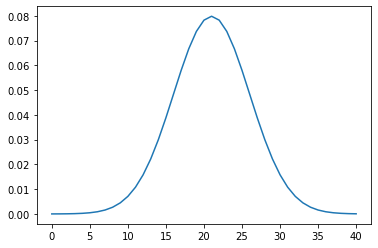

In [14]:
plt.plot(np.flip(tau_rev))

In [15]:
"""
# stack data matrices
u = np.zeros((s,t,p))
d = np.zeros((s,t))

for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u_tmp, _ = clean_npis(state_data,tf)
    d_tmp = clean_deaths(state_data,tf)
    
    # form data matrices
    #X_tmp = u[0:(t-1),]
    #X_tmp = u[0:t,]
    u[count,:,:] = u_tmp[0:t,]
    #d[count,] = d_tmp[0:t]
    d[count,] = d_tmp[lag:(t+lag)]
    
    #if count == 0:
    #    X = X_tmp
    #else:
    #    X = np.concatenate([X,X_tmp])
"""   

'\n# stack data matrices\nu = np.zeros((s,t,p))\nd = np.zeros((s,t))\n\nfor count,state in enumerate(states):\n    \n    n = get_state_pop(pops,state)\n    state_data = get_state_data(data,state)\n    u_tmp, _ = clean_npis(state_data,tf)\n    d_tmp = clean_deaths(state_data,tf)\n    \n    # form data matrices\n    #X_tmp = u[0:(t-1),]\n    #X_tmp = u[0:t,]\n    u[count,:,:] = u_tmp[0:t,]\n    #d[count,] = d_tmp[0:t]\n    d[count,] = d_tmp[lag:(t+lag)]\n    \n    #if count == 0:\n    #    X = X_tmp\n    #else:\n    #    X = np.concatenate([X,X_tmp])\n'

In [16]:
np.where(states == "Pennsylvania")

(array([38]),)

In [17]:
states[22]

'Michigan'

In [213]:
t = 365 # days to model
t_pred = 60 # number of days to predict ahead

tf = t+t_pred+10
# s = len(states)
num_states = 51 #number of states to model

#state_start = 34
starts = np.zeros(num_states)
n = np.zeros(num_states)
days_npi = np.zeros(num_states)
days_d = np.zeros(num_states)
# p = 13 # number of npis to use
# inds = list(range(p)) #npi indices
inds = list(range(7)) + list(range(9,13,1)) # remove int'l travel controls and public info campaigns (7,8)

# 10 most populous states (plus indiana)
states_list = np.array(
    [states[35], # ohio
     states[15], # indiana
     states[14], # illinois  
     states[22], # michigan       
     states[4], # california
     states[34], # new york 
     states[43], # texas     
     states[9], # florida  
     states[38], # pennsylvania
     states[10], # georgia
     states[27], # north carolina 
    ])
#states_to_model = states_list[0:num_states]
states_to_model = states

d0 = np.zeros(num_states)
#for count,state in enumerate(states[state_start:(num_states+state_start)]):
for count,state in enumerate(states_to_model):
    
    n_tmp = get_state_pop(pops,state)
    n[count] = n_tmp
    
    state_data = get_state_data(data,state)
    u_tmp, p = clean_npis(state_data,tf,inds)
    d_tmp = clean_deaths(state_data,tf)
    dates_tmp = get_dates(state_data,tf)
    
    start = np.min(np.where(d_tmp > 0))
#     if start <= cutoff:
#         start = 0
#     else: 
#         start = start - cutoff
    starts[count] = start
    days_npi[count] = t+t_pred-start
    days_d[count] = t-start
    d0[count] = np.sum(d_tmp[0:start])
    
    if count == 0:  
        u = u_tmp[start:(t+t_pred),]
        d = d_tmp[start:t]
        #d[0] += np.sum(d_tmp[0:start])
        d_pred = d_tmp[t:(t+t_pred)]
        dates = dates_tmp[start:(t+t_pred)]
    else:
        u = np.concatenate([u,u_tmp[start:(t+t_pred),]])
        dtmp = d_tmp[start:t]
        #dtmp[0] += np.sum(d_tmp[0:start])
        d = np.concatenate([d,dtmp])
        d_pred = np.concatenate([d_pred,d_tmp[t:(t+t_pred)]])
        dates = np.concatenate([dates,dates_tmp[start:(t+t_pred)]])

In [214]:
print(np.shape(u));
print(np.shape(d));
print(np.shape(dates))
t_npi = np.cumsum(np.concatenate([np.array([0]),days_npi])).astype(int); print(t_npi)
t_d = np.cumsum(np.concatenate([np.array([0]),days_d])).astype(int); print(t_d)

(17732, 11)
(14672,)
(17732,)
[    0   341   682  1024  1369  1731  2085  2433  2777  3112  3470  3824
  4158  4499  4839  5188  5538  5891  6241  6593  6939  7286  7625  7979
  8324  8672  9019  9358  9699 10038 10376 10719 11075 11416 11766 12121
 12525 12872 13223 13571 13918 14268 14623 14969 15318 15662 16014 16361
 16727 17074 17410 17732]
[    0   281   562   844  1129  1431  1725  2013  2297  2572  2870  3164
  3438  3719  3999  4288  4578  4871  5161  5453  5739  6026  6305  6599
  6884  7172  7459  7738  8019  8298  8576  8859  9155  9436  9726 10021
 10365 10652 10943 11231 11518 11808 12103 12389 12678 12962 13254 13541
 13847 14134 14410 14672]


In [215]:
print(n)

[  736732.  4849377.  2966369.  6731484. 38802500.  5355866.  3596677.
   658893.   935614. 19893297. 10097343.  1419561.  3107126.  1634464.
 12880580.  6596855.  2904021.  4413457.  4649676.  6745408.  5976407.
  1330089.  9909877.  5457173.  6063589.  2994079.  1023579.  9943964.
   739482.  1881503.  1326813.  8938175.  2085572.  2839099. 19746227.
 11594163.  3878051.  3970239. 12787209.  1055173.  4832482.   853175.
  6549352. 26956958.  2942902.  8326289.   626562.  7061530.  5757564.
  1850326.   584153.]


In [216]:
np.sum(np.isnan(u))

0

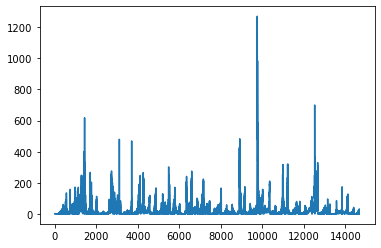

In [217]:
plt.plot(d)

In [218]:
print([d[t_d[j]] for j in range(num_states)])
print(d0)

[1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 2.0, 3.0, 2.0, 1.0, 1.0, 1.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 3.0, 1.0, 1.0]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]


In [219]:
ttotal = np.shape(d)[0]; ttotal
s = num_states; s

n_compartments = 5

# Plot NPIs over time

In [220]:
ts = t_npi
X = u

IndexError: index 11 is out of bounds for axis 1 with size 11

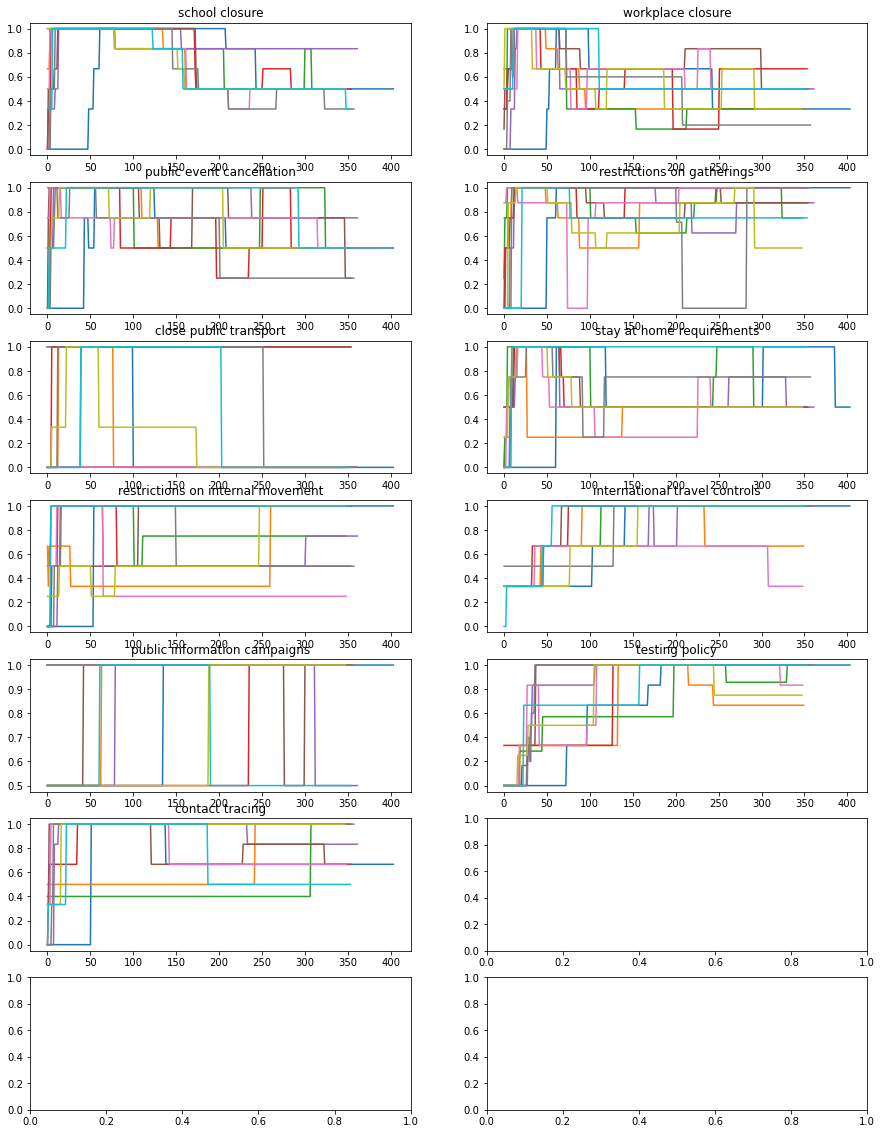

In [189]:
fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(15,20))

for j in range(s):
    axs[0,0].plot(X[ts[j]:ts[j+1],0])
    axs[0,0].set_title("school closure")
    
for j in range(s):
    axs[0,1].plot(X[ts[j]:ts[j+1],1])
    axs[0,1].set_title("workplace closure")
    
for j in range(s):
    axs[1,0].plot(X[ts[j]:ts[j+1],2])
    axs[1,0].set_title("public event cancellation")
    
for j in range(s):
    axs[1,1].plot(X[ts[j]:ts[j+1],3])
    axs[1,1].set_title("restrictions on gatherings")
    
for j in range(s):
    axs[2,0].plot(X[ts[j]:ts[j+1],4])
    axs[2,0].set_title("close public transport")   

for j in range(s):
    axs[2,1].plot(X[ts[j]:ts[j+1],5])
    axs[2,1].set_title("stay at home requirements")
    
for j in range(s):
    axs[3,0].plot(X[ts[j]:ts[j+1],6])
    axs[3,0].set_title("restrictions on internal movement")   

for j in range(s):
    axs[3,1].plot(X[ts[j]:ts[j+1],7])
    axs[3,1].set_title("international travel controls")  

for j in range(s):
    axs[4,0].plot(X[ts[j]:ts[j+1],8])
    axs[4,0].set_title("public information campaigns")   

for j in range(s):
    axs[4,1].plot(X[ts[j]:ts[j+1],9])
    axs[4,1].set_title("testing policy")  

for j in range(s):
    axs[5,0].plot(X[ts[j]:ts[j+1],10])
    axs[5,0].set_title("contact tracing")   

for j in range(s):
    axs[5,1].plot(X[ts[j]:ts[j+1],11])
    axs[5,1].set_title("facial coverings")  
    
for j in range(s):
    axs[6,0].plot(X[ts[j]:ts[j+1],12])
    axs[6,0].set_title("protect elderly") 
    
#plt.savefig("npi_variation.pdf")

## Additive linear control model

In [25]:
sir_bhm_code1 = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  int<lower=1> n_compartments; // number of compartments in epi model
  int<lower=0,upper=1> quadratic; // use quadratic matching technology? 
  
  array[s+1] int t;         // days of npi observations
  array[s+1] int t_d;         // days of death observations  
  array[s] int n_d;         // number of days of death observations    
  array[t_d[s+1]] int d;    // deaths
  matrix[t[s+1],p] u;  // NPIs  
  array[s] int n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
}
parameters {
  //real<lower=0> beta0; // global baseline contact parameter            
  //real<lower=0> beta_sd; // random effect sd       
  //vector[s] beta_diff; // normalized state-level difference  
  vector[s] beta0_s; 
  
  //vector[t[s+1]] beta_eps; // AR(1) error terms
  //vector<lower=0>[s] sigma; // beta_eps std dev
  //vector<lower=0,upper=1>[s] phi; // state-level AR(1) autocorrelation    
  
  simplex[p] rho; // global relative npi effects
  array[s] simplex[p] rho_s; // state-level relative npi effects
  real<lower=0> rho_scale; // random effect scale parameter on relative npi effects  
  
  //real<lower=0,upper=1> alpha; // global total npi effect  
  vector<lower=0,upper=1>[s] alpha_s; // state-level total npi effects
  //real<lower=0> alpha_scale; // random effect scale parameter on total npi effects  
  
  vector<lower=0>[s] kappa; // over-dispersion parameters
  
  real<lower=0,upper=1> ifr; // infection fatality rate
  //real<lower=0,upper=1> gamma;  // removal rate
  //real<lower=0,upper=1> delta; // incubation period
  //vector<lower=0.05,upper=0.35>[s] gamma;
  //vector<lower=0.05,upper=0.5>[s] delta; 
  vector<lower=0,upper=1>[s] gamma;
  vector<lower=0,upper=1>[s] delta;  
  
  //vector<lower=gamma,upper=5*gamma>[s] beta0_s;  
  
  array[s] simplex[n_compartments] x0; // initial states
}
transformed parameters {
  vector<lower=0>[t[s+1]] beta; // betas
  
  vector<lower=0,upper=1>[t[s+1]+s] sus; // proportion susceptible
  vector<lower=0,upper=1>[t[s+1]+s] exps; // proportion exposed  
  vector<lower=0,upper=1>[t[s+1]+s] inf; // proportion infected 
  
  vector<lower=0,upper=1>[t[s+1]] nu;  // new infections
  vector<lower=0>[t[s+1]] death_par;  // death mean
  
  //vector[s] beta0_s = beta0 + beta_sd * beta_diff; // state-level contact parameter 
  
  for(state in 1:s){ 
    if(quadratic == 0){
        //beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]) + beta_eps[(t[state]+1):t[state+1]];   
        beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]);      
    }
    else{
        //beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]).^2 + beta_eps[(t[state]+1):t[state+1]];   
        beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]).^2;      
    }
    
    sus[t[state]+1] = 0.000001 * x0[state,1] + 0.999999;
    exps[t[state]+1] = 0.000001 * x0[state,2];
    inf[t[state]+1] = 0.000001 * x0[state,3];
    
    for(day in 1:(t[state+1]-t[state])){
    
      //nu[t[state]+day] = beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      nu[t[state]+day] = delta[state] * exps[t[state]+day];
      
      //sus[t[state]+day+1] = sus[t[state]+day] - nu[t[state]+day];
      sus[t[state]+day+1] = sus[t[state]+day] - beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      exps[t[state]+day+1] = exps[t[state]+day] + beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day] - nu[t[state]+day];
      inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma[state]) + nu[t[state]+day]; 
      
      if(day <= cutoff){
        death_par[t[state]+day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[(t[state]+1):(t[state]+day)]);
        death_par[t[state]+day] += sum(tau_rev[1:(cutoff-day+1)])*(1-sus[t[state]+1]);
        death_par[t[state]+day] *= ifr*n[state];
        
      }else{
        death_par[t[state]+day] = n[state] * ifr * dot_product(tau_rev, nu[(t[state]+day-cutoff):(t[state]+day)]);
      }
    }
  }
}
model {
  //target += normal_lpdf(beta0 | 3 * 0.15, 0.15); // prior on beta0
  //target += normal_lpdf(beta_diff | 0, 1);       // prior log-density  
  target += normal_lpdf(beta0_s | 3 * gamma, gamma); // prior on beta0  

  //target += uniform_lpdf(phi | 0, 1);  // prior on AR(1) autocorrelation parameters
  
  //target += uniform_lpdf(alpha | 0, 1); // uniform prior on total effect
  target += uniform_lpdf(alpha_s | 0, 1); // uniform prior on total effect
  target += dirichlet_lpdf(rho | rep_vector(1, p)); // uniform prior on relative effects
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  //target += uniform_lpdf(gamma | 0, 1);
  //target += uniform_lpdf(delta | 0, 1);  
  target += normal_lpdf(gamma | 0.15, 0.05);
  target += normal_lpdf(delta | 0.15, 0.05);
  
  //target += -log(beta_sd);  // improper prior on scale parameters  
  target += -log(rho_scale);
  //target += -log(alpha_scale);
  
  //target += -log(kappa);
  //target += -log(sigma);    

  for(state in 1:s){
      //target += neg_binomial_2_lpmf(d[(t[state]+1):t[state+1]] | death_par[(t[state]+1):t[state+1]], 1/kappa[state]); // likelihood on deaths
      target += neg_binomial_2_lpmf(d[(t_d[state]+1):t_d[state+1]] | death_par[(t[state]+1):(t[state]+n_d[state])], 1/kappa[state]); // likelihood on deaths  
  
      target += dirichlet_lpdf(rho_s[state] | rho_scale * rho); // relative npi random effects
      //target += beta_lpdf(alpha_s[state] | alpha_scale * alpha, alpha_scale * (1-alpha)); // total npi random effects

      //target += normal_lpdf(beta_eps[t[state]+1] | 0, sigma[state]);
      //target += normal_lpdf(beta_eps[(t[state]+2):t[state+1]] | phi[state] * beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]); // AR(1) model on beta_eps

      target += dirichlet_lpdf(x0[state] | rep_vector(1,n_compartments)); // uniform prior on initial states
    
      //target += -log(sigma[state]); // improper prior on scale parameters
      target += -log(kappa[state]); // improper prior on scale parameters
  }
}
generated quantities {
  array[t[s+1]] int dhat;
  for(state in 1:s){
      dhat[(t[state]+1):t[state+1]] = neg_binomial_2_rng(death_par[(t[state]+1):t[state+1]], 1/kappa[state]);
  }
}
"""

In [221]:
sir_bhm_code1_mu = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  int<lower=1> n_compartments; // number of compartments in epi model
  int<lower=0,upper=1> quadratic; // use quadratic matching technology? 
  
  array[s+1] int t;         // days of npi observations
  array[s+1] int t_d;         // days of death observations  
  array[s] int n_d;         // number of days of death observations    
  array[t_d[s+1]] int d;    // deaths over time
  array[s] int d0; // initial deaths
  matrix[t[s+1],p] u;  // NPIs  
  array[s] int n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
  
  real<lower=0,upper=1> ifr;
  //real<lower=0,upper=1> gamma;
  //real<lower=0,upper=1> delta;
  //real<lower=0,upper=1> mu;
}
parameters {
  real<lower=0> beta0; // global baseline contact parameter            
  real<lower=0> beta_sd; // random effect sd       
  vector[s] beta_diff; // normalized state-level difference  
  //vector[s] beta0_s; 
  
  vector[t[s+1]] beta_eps; // AR(1) error terms
  vector<lower=0>[s] sigma; // beta_eps std dev
  //vector<lower=0,upper=1>[s] phi; // state-level AR(1) autocorrelation    
  
  simplex[p] rho; // global relative npi effects
  array[s] simplex[p] rho_s; // state-level relative npi effects
  real<lower=0> rho_scale; // random effect scale parameter on relative npi effects  
  
  real<lower=0,upper=1> alpha; // global total npi effect  
  vector<lower=0,upper=1>[s] alpha_s; // state-level total npi effects
  real<lower=0> alpha_scale; // random effect scale parameter on total npi effects  
  
  vector<lower=0>[s] kappa; // over-dispersion parameters
  
  //real<lower=0,upper=1> ifr; // infection fatality rate
  real<lower=0,upper=1> gamma;  // removal rate
  real<lower=0,upper=1> delta; // incubation period 
  //real<lower=0,upper=1> mu; // death rate
  real<lower=0,upper=1> mu_i;   
  real<lower=0,upper=1> mu_r;   
  
  //vector<lower=0,upper=1>[s] gamma;  
  //vector<lower=0,upper=1>[s] delta;  
  //vector<lower=0,upper=1>[s] mu;   
  //vector<lower=0,upper=1>[s] mu_i;   
  //vector<lower=0,upper=1>[s] mu_r;  
  
  array[s] simplex[n_compartments] x0; // initial states
}
transformed parameters {
  vector[t[s+1]] beta; // betas
  
  vector[t[s+1]+s] sus; // proportion susceptible
  vector[t[s+1]+s] exps; // proportion exposed  
  vector[t[s+1]+s] inf; // proportion infected 
  vector[t[s+1]+s] rem; // proportion removed   
  
  vector[t[s+1]] nu;  // new infections
  vector[t[s+1]] death_par;  // death mean
  
  vector[s] beta0_s = beta0 + beta_sd * beta_diff; // state-level contact parameter 
  //vector[t[s+1]] log_beta_eps = log(beta_eps);
  
  for(state in 1:s){ 
    if(quadratic == 0){
        beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]) + beta_eps[(t[state]+1):t[state+1]];   
        //beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]);      
    }
    else{
        beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]).^2 + beta_eps[(t[state]+1):t[state+1]];   
        //beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]).^2;      
    }
    
    sus[t[state]+1] = 0.01 * x0[state,1] + 0.99;
    exps[t[state]+1] = 0.01 * x0[state,2];
    inf[t[state]+1] = 0.01 * x0[state,3];
    rem[t[state]+1] = 0.01 * x0[state,4];
    
    for(day in 1:(t[state+1]-t[state])){
      //nu[t[state]+day] = beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      nu[t[state]+day] = delta * exps[t[state]+day];
      death_par[t[state]+day] = ifr * (mu_i * inf[t[state]+day] + mu_r * rem[t[state]+day]);
      //death_par[t[state]+day] = ifr * mu * rem[t[state]+day];
      
      //sus[t[state]+day+1] = sus[t[state]+day] - nu[t[state]+day];
      sus[t[state]+day+1] = sus[t[state]+day] - beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      exps[t[state]+day+1] = exps[t[state]+day] + beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day] - nu[t[state]+day];
      inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma) + nu[t[state]+day] - ifr * mu_i * inf[t[state]+day]; 
      //inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma[state]) + nu[t[state]+day]; 
      rem[t[state]+day+1] = inf[t[state]+day]*gamma - ifr * mu_r * rem[t[state]+day];
      //rem[t[state]+day+1] = inf[t[state]+day]*gamma[state] - death_par[t[state]+day];
    }
  }
}
model {
  //target += normal_lpdf(beta0 | 3 * 0.15, 0.15); // prior on beta0
  target += normal_lpdf(beta_diff | 0, 1);       // prior log-density  
  //target += normal_lpdf(beta0_s | 3 * gamma, 0.5 * gamma); // prior on beta0  
  target += normal_lpdf(beta0 | 3 * gamma, 0.5 * gamma); // prior on beta0    

  //target += uniform_lpdf(phi | 0, 1);  // prior on AR(1) autocorrelation parameters
  
  target += uniform_lpdf(alpha | 0, 1); // uniform prior on total effect
  //target += uniform_lpdf(alpha_s | 0, 1); // uniform prior on total effect
  target += dirichlet_lpdf(rho | rep_vector(1, p)); // uniform prior on relative effects
  
  //target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  //target += uniform_lpdf(gamma | 0, 1);
  //target += uniform_lpdf(delta | 0, 1);  
  target += normal_lpdf(gamma | 0.15, 0.025);
  target += normal_lpdf(delta | 0.15, 0.025);
  //target += normal_lpdf(mu | 0.07, 0.015);
  target += normal_lpdf(mu_i | 0.05, 0.005);
  target += normal_lpdf(mu_r | 0.07, 0.015);
  
  target += -log(beta_sd);  // improper prior on scale parameters  
  target += -log(rho_scale);
  target += -log(alpha_scale);
  
  //target += -log(kappa);
  //target += -log(sigma);    

  for(state in 1:s){
      //target += neg_binomial_2_lpmf(d0[state] | ifr * rem[t[state]+1], 1/kappa[state]);
      target += neg_binomial_2_lpmf(d0[state] | 0.01 * x0[state,5], 1/kappa[state]);
  
      //target += neg_binomial_2_lpmf(d[(t[state]+1):t[state+1]] | death_par[(t[state]+1):t[state+1]], 1/kappa[state]); // likelihood on deaths
      target += neg_binomial_2_lpmf(d[(t_d[state]+1):t_d[state+1]] | n[state]*death_par[(t[state]+1):(t[state]+n_d[state])], 1/kappa[state]); // likelihood on deaths  
  
      target += dirichlet_lpdf(rho_s[state] | rho_scale * rho); // relative npi random effects
      target += beta_lpdf(alpha_s[state] | alpha_scale * alpha, alpha_scale * (1-alpha)); // total npi random effects
      
      //if(quadratic == 0){
      //    target += normal_lpdf(beta[(t[state]+1):t[state+1]] | beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]), sigma[state]);
      //}
      //else{
      //    target += normal_lpdf(beta[(t[state]+1):t[state+1]] | beta0_s[state] * (1 - alpha_s[state] * u[(t[state]+1):t[state+1]] * rho_s[state]).^2, sigma[state]);
      //}
      //target += normal_lpdf(log_beta_eps[t[state]+1] | 0, sigma[state]);
      //target += normal_lpdf(log_beta_eps[(t[state]+2):t[state+1]] | phi[state] * log_beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]); // AR(1) model on beta_eps
      //target += normal_lpdf(beta_eps[t[state]+1] | 0, sigma[state]);
      //target += normal_lpdf(beta_eps[(t[state]+2):t[state+1]] | phi[state] * beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]);
      target += normal_lpdf(beta_eps[t[state]+1] | 0, sigma[state]);
      target += normal_lpdf(beta_eps[(t[state]+2):t[state+1]] | beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]);

      target += dirichlet_lpdf(x0[state] | rep_vector(1,n_compartments)); // uniform prior on initial states
    
      target += -log(sigma[state]); // improper prior on scale parameters
      target += -log(kappa[state]); // improper prior on scale parameters
  }
}
generated quantities {
  array[t[s+1]] int dhat;
  for(state in 1:s){
      dhat[(t[state]+1):t[state+1]] = neg_binomial_2_rng(n[state]*death_par[(t[state]+1):t[state+1]], 1/kappa[state]);
  }
}
"""

In [222]:
init_dict1 = {"beta0": 0.3, 
              "beta0_s": 0.45 * np.ones(s),
             "beta_eps": np.zeros(ttotal), 
             "gamma": 0.15 * np.ones(s),
             "delta": 0.15 * np.ones(s),
             "ifr": 0.0068, 
             "alpha": 0.9, 
             "alpha_s" : 0.9 * np.ones(s),
             "rho": np.ones(p)/p, 
             "rho_s" : np.ones([s,p])/p,
             "phi" : 0.5*np.ones(s), 
             "beta_diff" : np.zeros(s),
             "beta_sd" : 0.05,  
             "alpha_scale" : 1,
             "rho_scale" : 1,
             "sigma": 0.05 * np.ones(s),
             "kappa" : np.ones(s)/1000,
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

In [223]:
init_dict2 = {"beta0": 0.375, 
             #"beta_eps": np.zeros(ttotal), 
             "gamma": 0.15,
             "delta": 0.15,
             "ifr": 0.0068, 
             "alpha": 0.5, 
             "alpha_s" : 0.5 * np.ones(s),
             "rho": np.ones(p)/p, 
             "rho_s" : np.ones([s,p])/p,
             #"phi" : 0.5*np.ones(s), 
             "beta_diff" : np.zeros(s),
             "rho_diff" : np.zeros([s,p]),
             "beta_sd" : 0.05,  
             "alpha_scale" : 1,
             "rho_scale" : 1,
             #"sigma": 0.05 * np.ones(s),
             "kappa" : np.ones(s),
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

In [224]:
init_dict1_mu = {"beta0": 0.6, 
              "beta0_s": 0.6 * np.ones(s),
             "beta_eps": np.zeros(ttotal), #np.zeros(ttotal), 
             "gamma": 0.15, #* np.ones(s),
             "delta": 0.15, #* np.ones(s),
             #"mu": 0.1 * np.ones(s),
             "mu_i": 0.05, #* np.ones(s),
             "mu_r": 0.05, #* np.ones(s),    
             "ifr": 0.0068, 
             "alpha": 0.2, 
             "alpha_s" : 0.2 * np.ones(s),
             "rho": np.ones(p)/p, 
             "rho_s" : np.ones([s,p])/p,
             "phi" : 0.5*np.ones(s), 
             "beta_diff" : np.zeros(s),
             "beta_sd" : 0.01,  
             "alpha_scale" : 1,
             "rho_scale" : 1,
             "sigma": 0.01 * np.ones(s),
             "kappa" : np.ones(s)/1000,
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

## Multiplicative control model

In [636]:
sir_bhm_code3 = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  int<lower=1> n_compartments; // number of compartments in epi model
  int<lower=0,upper=1> quadratic; // use quadratic matching technology? 
  
  array[s+1] int t;         // days of npi observations
  array[s+1] int t_d;         // days of death observations  
  array[s] int n_d;         // number of days of death observations    
  array[t_d[s+1]] int d;    // deaths
  matrix[t[s+1],p] u;  // NPIs  
  array[s] int n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
}
parameters {
  real<lower=0> beta0; // global baseline contact parameter            
  real<lower=0> beta_sd; // random effect sd       
  vector[s] beta_diff; // normalized state-level difference  
  
  //vector[t[s+1]] beta_eps; // AR(1) error terms
  //vector<lower=0>[s] sigma; // beta_eps std dev
  //vector<lower=0,upper=1>[s] phi; // state-level AR(1) autocorrelation    
  
  vector<lower=0,upper=1>[p] rho; // global relative npi effects
  array[s] vector<lower=0,upper=1>[p] rho_s; // state-level relative npi effects
  //real<lower=0> rho_scale; // random effect scale parameter on relative npi effects 
  vector<lower=0>[p] rho_scale; // random effect scale parameter on relative npi effects  
  
  vector<lower=0>[s] kappa; // over-dispersion parameters
  
  real<lower=0,upper=1> gamma;  // removal rate
  real<lower=0,upper=1> ifr; // infection fatality rate
  real<lower=0,upper=1> delta; // incubation period
  
  array[s] simplex[n_compartments] x0; // initial states
  //vector[s] s0_tilde; 
  //vector[s] i0_tilde;
}
transformed parameters {
  vector[t[s+1]] beta; // betas
  
  vector[t[s+1]+s] sus; // proportion susceptible
  vector[t[s+1]+s] exps; // proportion exposed  
  vector[t[s+1]+s] inf; // proportion infected 
  
  //matrix[t[s+1]+s,2] x;  // SIR state 
  //vector<lower=0,upper=1>[s] s0 = Phi(s0_tilde);  // initial susceptible
  //vector<lower=0,upper=1>[s] i0 = Phi(i0);  // initial infectious
  //vector<lower=0,upper=1>[s] i0 = 1 - s0;  // initial infectious   
  
  vector[t[s+1]] nu;  // new infections
  vector<lower=0>[t[s+1]] death_par;  // death mean
  
  vector[s] beta0_s = beta0 + beta_sd * beta_diff; // state-level contact parameter 
  
  for(state in 1:s){   
    
    sus[t[state]+1] = 0.000001 * x0[state,1] + 0.999999;
    exps[t[state]+1] = 0.000001 * x0[state,2];
    inf[t[state]+1] = 0.000001 * x0[state,3];
    
    //x[t[state]+1,1] = s0[state];
    //x[t[state]+1,2] = 1-s0[state];
    
    for(day in 1:(t[state+1]-t[state])){
      beta[t[state]+day] = beta0_s[state] * prod(1 - rho_s[state]' .* u[t[state]+day]); 
      //beta[t[state]+day] = beta0_s[state] * prod(1 - rho_s[state]' .* u[t[state]+day]) + beta_eps[t[state]+day];
    
      //nu[t[state]+day] = beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      nu[t[state]+day] = delta * exps[t[state]+day];
      
      //sus[t[state]+day+1] = sus[t[state]+day] - nu[t[state]+day];
      sus[t[state]+day+1] = sus[t[state]+day] - beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      exps[t[state]+day+1] = exps[t[state]+day] + beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day] - nu[t[state]+day];
      inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma) + nu[t[state]+day]; 
      
      //nu[t[state]+day] = beta[t[state]+day] * x[t[state]+day,1] * x[t[state]+day,2];
      //x[t[state]+day+1,1] = x[t[state]+day,1] - nu[t[state]+day];
      //x[t[state]+day+1,2] = x[t[state]+day,2]*(1-gamma) + nu[t[state]+day];
      
      if(day <= cutoff){
      
        death_par[t[state]+day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[(t[state]+1):(t[state]+day)]);
        death_par[t[state]+day] += sum(tau_rev[1:(cutoff-day+1)])*(1-sus[t[state]+1]);
        death_par[t[state]+day] *= ifr*n[state];
        
        //death_par[t[state]+day] = sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[(t[state]+1):(t[state]+day)]);
        //death_par[t[state]+day] += sum(tau_rev[1:(cutoff-day+1)])*(1-s0[state]);
        //death_par[t[state]+day] *= ifr*n[state];
        
      }else{
        death_par[t[state]+day] = n[state] * ifr * dot_product(tau_rev, nu[(t[state]+day-cutoff):(t[state]+day)]);
        //death_par[t[state]+day] = n[state] * ifr * sum(tau_rev .* nu[(t[state]+day-cutoff):(t[state]+day)]);
      }
    }
  }
}
model {
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15); // prior on beta0
  target += normal_lpdf(beta_diff | 0, 1);       // prior log-density  

  //target += uniform_lpdf(phi | 0, 1);  // prior on AR(1) autocorrelation parameters
  
  target += uniform_lpdf(rho | 0, 1); // uniform prior on NPI effects
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  //target += uniform_lpdf(gamma | 0, 1);
  //target += uniform_lpdf(delta | 0, 1);  
  target += normal_lpdf(gamma | 0.15, 0.05);
  target += normal_lpdf(delta | 0.15, 0.05);
  
  target += -log(beta_sd);  // improper prior on scale parameters  
  target += -log(rho_scale);
  
  //target += -log(kappa);
  //target += -log(sigma);    

  for(state in 1:s){
      //target += neg_binomial_2_lpmf(d[(t[state]+1):t[state+1]] | death_par[(t[state]+1):t[state+1]], 1/kappa[state]); // likelihood on deaths
      target += neg_binomial_2_lpmf(d[(t_d[state]+1):t_d[state+1]] | death_par[(t[state]+1):(t[state]+n_d[state])], 1/kappa[state]); // likelihood on deaths  
  
      target += beta_lpdf(rho_s[state] | rho_scale .* rho, rho_scale .* (1-rho)); // npi random effects

      //target += normal_lpdf(beta_eps[t[state]+1] | 0, sigma[state]);
      //target += normal_lpdf(beta_eps[(t[state]+2):t[state+1]] | phi[state] * beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]); // AR(1) model on beta_eps

      target += dirichlet_lpdf(x0[state] | rep_vector(1,n_compartments)); // uniform prior on initial states
    
      //target += -log(sigma[state]); // improper prior on scale parameters
      target += -log(kappa[state]); // improper prior on scale parameters
  }
}
generated quantities {
  array[t[s+1]] int dhat;
  for(state in 1:s){
      dhat[(t[state]+1):t[state+1]] = neg_binomial_2_rng(death_par[(t[state]+1):t[state+1]], 1/kappa[state]);
  }
}
"""

In [ ]:
init_dict3 = {"beta0": 0.375, 
             #"beta_eps": np.zeros(ttotal), 
             "gamma": 0.15,
             "delta": 0.15,
             "ifr": 0.0068, 
             "rho": np.ones(p)/p, 
             "rho_s" : np.ones([s,p])/p,
             #"phi" : 0.5*np.ones(s), 
             "beta_diff" : np.zeros(s),
             "beta_sd" : 0.05,  
             "alpha_scale" : 1,
             "rho_scale" : np.ones(p),
             #"sigma": 0.05 * np.ones(s),
             "kappa" : np.ones(s),
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

## Log linear control model

In [158]:
sir_bhm_code4 = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  int<lower=1> n_compartments; // number of compartments in epi model
  int<lower=0,upper=1> quadratic; // use quadratic matching technology? 
  
  array[s+1] int t;         // days of npi observations
  array[s+1] int t_d;         // days of death observations  
  array[s] int n_d;         // number of days of death observations    
  array[t_d[s+1]] int d;    // deaths
  matrix[t[s+1],p] u;  // NPIs  
  array[s] int n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
}
parameters {
  //real<lower=0> beta0; // global baseline contact parameter            
  //real<lower=0> beta_sd; // random effect sd       
  //vector[s] beta_diff; // normalized state-level difference  
  vector<lower=0>[s] beta0;
  
  vector[t[s+1]] beta_eps; // AR(1) error terms
  vector<lower=0>[s] sigma; // beta_eps std dev
  vector<lower=0,upper=1>[s] phi; // state-level AR(1) autocorrelation    
  
  vector[p] rho; // global relative npi effects
  array[s] vector[p] rho_diff; // state-level relative npi effects
  vector<lower=0>[p] rho_scale; // random effect scale parameter on relative npi effects  
  
  vector<lower=0>[s] kappa; // over-dispersion parameters
  
  real<lower=0,upper=1> ifr; // infection fatality rate
  //real<lower=0,upper=1> gamma;  // removal rate  
  //real<lower=0,upper=1> delta; // incubation period
  vector<lower=0,upper=1>[s] gamma;
  vector<lower=0,upper=1>[s] delta;
  
  array[s] simplex[n_compartments] x0; // initial states
}
transformed parameters {
  vector[t[s+1]] beta; // betas
  array[s] vector[p] rho_s; // state-level relative npi effects    
  
  vector[t[s+1]+s] sus; // proportion susceptible
  vector[t[s+1]+s] exps; // proportion exposed  
  vector[t[s+1]+s] inf; // proportion infected 
  
  vector[t[s+1]] nu;  // new infections
  vector[t[s+1]] death_par;  // death mean
  
  //real log_beta0 = log(beta0);
  //vector[s] log_beta0_s = log_beta0 + beta_sd * beta_diff; // state-level contact parameter 
  vector[s] log_beta0_s = log(beta0);
  
  for(state in 1:s){     
    rho_s[state] = rho + rho_scale .* rho_diff[state];
    beta[(t[state]+1):t[state+1]] = exp(log_beta0_s[state] + u[(t[state]+1):t[state+1]] * rho_s[state] + beta_eps[(t[state]+1):t[state+1]]);
    //beta[(t[state]+1):t[state+1]] = exp(log_beta0_s[state] + u[(t[state]+1):t[state+1]] * rho_s[state]);
    
    sus[t[state]+1] = 0.000001 * x0[state,1] + 0.999999;
    exps[t[state]+1] = 0.000001 * x0[state,2];
    inf[t[state]+1] = 0.000001 * x0[state,3];
    
    for(day in 1:(t[state+1]-t[state])){
      //nu[t[state]+day] = beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      //nu[t[state]+day] = delta * exps[t[state]+day];
      nu[t[state]+day] = delta[state] * exps[t[state]+day];
      
      //sus[t[state]+day+1] = sus[t[state]+day] - nu[t[state]+day];
      sus[t[state]+day+1] = sus[t[state]+day] - beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      exps[t[state]+day+1] = exps[t[state]+day] + beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day] - nu[t[state]+day];
      //inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma) + nu[t[state]+day]; 
      inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma[state]) + nu[t[state]+day]; 
      
      if(day <= cutoff){
        death_par[t[state]+day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[(t[state]+1):(t[state]+day)]);
        death_par[t[state]+day] += sum(tau_rev[1:(cutoff-day+1)])*(1-sus[t[state]+1]);
        death_par[t[state]+day] *= ifr*n[state];
        
      }else{
        death_par[t[state]+day] = n[state] * ifr * dot_product(tau_rev, nu[(t[state]+day-cutoff):(t[state]+day)]);
      }
    }
  }
}
model {
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15); // prior on beta0
  //target += normal_lpdf(beta_diff | 0, 1);       // prior log-density  

  target += uniform_lpdf(phi | 0, 1);  // prior on AR(1) autocorrelation parameters
  
  target += normal_lpdf(rho | 0, 1); // prior on NPI effects  
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  //target += uniform_lpdf(gamma | 0, 1);
  //target += uniform_lpdf(delta | 0, 1);  
  target += normal_lpdf(gamma | 0.15, 0.05);
  target += normal_lpdf(delta | 0.15, 0.05);
  
  //target += -log(beta_sd);  // improper prior on scale parameters  
  target += -log(rho_scale);
  
  target += -log(kappa);
  target += -log(sigma);    

  for(state in 1:s){
      target += normal_lpdf(rho_diff[state] | 0, 1); 
  
      //target += neg_binomial_2_lpmf(d[(t[state]+1):t[state+1]] | death_par[(t[state]+1):t[state+1]], 1/kappa[state]); // likelihood on deaths
      target += neg_binomial_2_lpmf(d[(t_d[state]+1):t_d[state+1]] | death_par[(t[state]+1):(t[state]+n_d[state])], 1/kappa[state]); // likelihood on deaths  

      target += normal_lpdf(beta_eps[t[state]+1] | 0, sigma[state]);
      target += normal_lpdf(beta_eps[(t[state]+2):t[state+1]] | phi[state] * beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]); // AR(1) model on beta_eps

      target += dirichlet_lpdf(x0[state] | rep_vector(1,n_compartments)); // uniform prior on initial states
    
      //target += -log(sigma[state]); // improper prior on scale parameters
      //target += -log(kappa[state]); // improper prior on scale parameters
  }
}
generated quantities {
  array[t[s+1]] int dhat;
  for(state in 1:s){
      dhat[(t[state]+1):t[state+1]] = neg_binomial_2_rng(death_par[(t[state]+1):t[state+1]], 1/kappa[state]);
  }
}
"""

In [219]:
sir_bhm_code4_mu = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  int<lower=1> n_compartments; // number of compartments in epi model
  int<lower=0,upper=1> quadratic; // use quadratic matching technology? 
  
  array[s+1] int t;         // days of npi observations
  array[s+1] int t_d;         // days of death observations  
  array[s] int n_d;         // number of days of death observations    
  array[t_d[s+1]] int d;    // deaths
  matrix[t[s+1],p] u;  // NPIs  
  array[s] int n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
}
parameters {
  //real<lower=0> beta0; // global baseline contact parameter            
  //real<lower=0> beta_sd; // random effect sd       
  //vector[s] beta_diff; // normalized state-level difference  
  vector<lower=0>[s] beta0;
  
  vector[t[s+1]] beta_eps; // AR(1) error terms
  vector<lower=0>[s] sigma; // beta_eps std dev
  vector<lower=0,upper=1>[s] phi; // state-level AR(1) autocorrelation    
  
  vector[p] rho; // global relative npi effects
  array[s] vector[p] rho_diff; // state-level relative npi effects
  vector<lower=0>[p] rho_scale; // random effect scale parameter on relative npi effects  
  
  vector<lower=0>[s] kappa; // over-dispersion parameters
  
  real<lower=0,upper=1> ifr; // infection fatality rate
  //real<lower=0,upper=1> gamma;  // removal rate  
  //real<lower=0,upper=1> delta; // incubation period
  vector<lower=0,upper=1>[s] gamma;
  vector<lower=0,upper=1>[s] delta;
  vector<lower=0,upper=1>[s] mu;  
  
  array[s] simplex[n_compartments] x0; // initial states
}
transformed parameters {
  vector[t[s+1]] beta; // betas
  array[s] vector[p] rho_s; // state-level relative npi effects    
  
  vector[t[s+1]+s] sus; // proportion susceptible
  vector[t[s+1]+s] exps; // proportion exposed  
  vector[t[s+1]+s] inf; // proportion infected 
  vector[t[s+1]+s] rem; // proportion removed   
  
  vector[t[s+1]] nu;  // new infections
  vector[t[s+1]] death_par;  // death mean
  
  //real log_beta0 = log(beta0);
  //vector[s] log_beta0_s = log_beta0 + beta_sd * beta_diff; // state-level contact parameter 
  vector[s] log_beta0_s = log(beta0);
  
  for(state in 1:s){     
    rho_s[state] = rho + rho_scale .* rho_diff[state];
    beta[(t[state]+1):t[state+1]] = exp(log_beta0_s[state] + u[(t[state]+1):t[state+1]] * rho_s[state] + beta_eps[(t[state]+1):t[state+1]]);
    //beta[(t[state]+1):t[state+1]] = exp(log_beta0_s[state] + u[(t[state]+1):t[state+1]] * rho_s[state]);
    
    sus[t[state]+1] = 0.000001 * x0[state,1] + 0.999999;
    exps[t[state]+1] = 0.000001 * x0[state,2];
    inf[t[state]+1] = 0.000001 * x0[state,3];
    rem[t[state]+1] = 0.000001 * x0[state,4];
    
    for(day in 1:(t[state+1]-t[state])){
      //nu[t[state]+day] = beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      nu[t[state]+day] = delta[state] * exps[t[state]+day];
      death_par[t[state]+day] = ifr * mu[state] * rem[t[state]+day];
      
      //sus[t[state]+day+1] = sus[t[state]+day] - nu[t[state]+day];
      sus[t[state]+day+1] = sus[t[state]+day] - beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day];
      exps[t[state]+day+1] = exps[t[state]+day] + beta[t[state]+day] * sus[t[state]+day] * inf[t[state]+day] - nu[t[state]+day];
      inf[t[state]+day+1] = inf[t[state]+day]*(1-gamma[state]) + nu[t[state]+day]; 
      rem[t[state]+day+1] = inf[t[state]+day]*gamma[state] - death_par[t[state]+day]; 
    }
  }
}
model {
  //target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15); // prior on beta0
  //target += normal_lpdf(beta_diff | 0, 1);       // prior log-density  
  target += normal_lpdf(beta0 | 3 * gamma, gamma); // prior on beta0

  target += uniform_lpdf(phi | 0, 1);  // prior on AR(1) autocorrelation parameters
  
  target += normal_lpdf(rho | 0, 1); // prior on NPI effects  
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  //target += uniform_lpdf(gamma | 0, 1);
  //target += uniform_lpdf(delta | 0, 1);  
  //target += normal_lpdf(gamma | 0.15, 0.05);
  //target += normal_lpdf(delta | 0.15, 0.05);
  target += normal_lpdf(gamma | 0.15, 0.075);
  target += normal_lpdf(delta | 0.15, 0.075);
  target += normal_lpdf(mu | 0.1, 0.05);  
  
  //target += -log(beta_sd);  // improper prior on scale parameters  
  target += -log(rho_scale);
  
  target += -log(kappa);
  target += -log(sigma);    

  for(state in 1:s){
      target += normal_lpdf(rho_diff[state] | 0, 1); 
  
      //target += neg_binomial_2_lpmf(d[(t[state]+1):t[state+1]] | death_par[(t[state]+1):t[state+1]], 1/kappa[state]); // likelihood on deaths
      target += neg_binomial_2_lpmf(d[(t_d[state]+1):t_d[state+1]] | n[state]*death_par[(t[state]+1):(t[state]+n_d[state])], 1/kappa[state]); // likelihood on deaths  

      target += normal_lpdf(beta_eps[t[state]+1] | 0, sigma[state]);
      target += normal_lpdf(beta_eps[(t[state]+2):t[state+1]] | phi[state] * beta_eps[(t[state]+1):(t[state+1]-1)], sigma[state]); // AR(1) model on beta_eps

      target += dirichlet_lpdf(x0[state] | rep_vector(1,n_compartments)); // uniform prior on initial states
    
      //target += -log(sigma[state]); // improper prior on scale parameters
      //target += -log(kappa[state]); // improper prior on scale parameters
  }
}
generated quantities {
  array[t[s+1]] int dhat;
  for(state in 1:s){
      dhat[(t[state]+1):t[state+1]] = neg_binomial_2_rng(n[state]*death_par[(t[state]+1):t[state+1]], 1/kappa[state]);
  }
}
"""

In [220]:
init_dict4 = {"beta0": 0.45 * np.ones(s), 
             "beta_eps": np.zeros(ttotal), 
             "gamma": 0.15,
             "delta": 0.15,
             "ifr": 0.0068, 
             "rho": np.zeros(p), 
             "phi" : 0.5*np.ones(s), 
             "beta_diff" : np.zeros(s),
             "rho_diff" : np.zeros([s,p]),
             "beta_sd" : 1,
             "rho_scale" : np.ones(p),
             "sigma": 0.05 * np.ones(s),
             "kappa" : np.ones(s)/100,
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

In [221]:
init_dict4_mu = {"beta0": 0.6 * np.ones(s), 
             "beta_eps": np.zeros(ttotal), 
             "gamma": 0.15 * np.ones(s),
             "delta": 0.15 * np.ones(s),
             "mu": 0.1 * np.ones(s), 
             "ifr": 0.0068, 
             "rho": np.zeros(p), 
             "phi" : 0.9 * np.ones(s), 
             "beta_diff" : np.zeros(s),
             "rho_diff" : np.zeros([s,p]),
             "beta_sd" : 1,
             "rho_scale" : np.ones(p),
             "sigma": 0.05 * np.ones(s),
             "kappa" : np.ones(s)/100,
             "x0" : np.ones([s,n_compartments])/n_compartments
             }

## Fit the model

In [225]:
code = sir_bhm_code1_mu
init_dict = init_dict1_mu

In [226]:
sir_bhm_data = {"p" : p, "s" : s, "t" : t_npi, "t_d" : t_d, "n_d" : days_d.astype(int), 
            "d" : d.astype(int), "u" : u, "n" : n.astype(int),
            "cutoff" : cutoff, "tau_rev" : tau_rev, 
            "n_compartments" : n_compartments, 'quadratic':0, 'ifr': 0.0068, 'd0':d0.astype(int),
            "delta": 1/7, "gamma": 1/7, "mu": 1/14    
           }

In [227]:
posterior = stan.build(code, data=sir_bhm_data)

Building...



Building: found in cache, done.Messages from stanc:


In [228]:
print(s); print(p);

51
11


In [230]:
n_chains = 2

fit = posterior.sample(num_chains=n_chains, num_samples=250, num_warmup = 250, save_warmup = False,
                       init=[init_dict for k in range(n_chains)])

# fit = posterior.sample(num_chains=n_chains, num_samples=250, num_warmup = 750, save_warmup = False)

Sampling:   0%
Sampling:   0% (1/1000)
Sampling:   0% (2/1000)

In [37]:
#np.max(az.summary(fit)['r_hat'])

In [38]:
#az.summary(fit)['r_hat']

In [199]:
df = fit.to_frame()

KeyError: 'ifr'

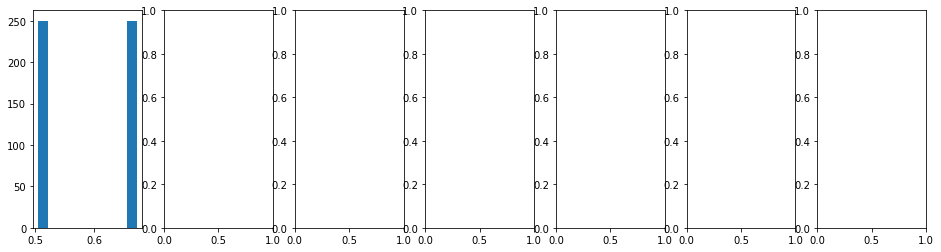

In [132]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=1, ncols=7, figsize=(16,4))

axs[0].hist(df["beta0"])#/df["gamma"]); axs[0].set_title('beta0/gamma'); 
axs[1].hist(df["ifr"]); axs[1].set_title('ifr');
axs[2].hist(df["gamma"]); axs[2].set_title('gamma');
axs[3].hist(df["delta"]); axs[3].set_title('delta');
axs[4].hist(df["alpha"]); axs[4].set_title('alpha');
axs[5].hist(df["rho_scale"]); axs[5].set_title('rho_scale');
axs[6].hist(df["alpha_scale"]); axs[6].set_title('alpha_scale');
axs[7].hist(df["beta_sd"]); axs[7].set_title('beta_sd');

plt.show()

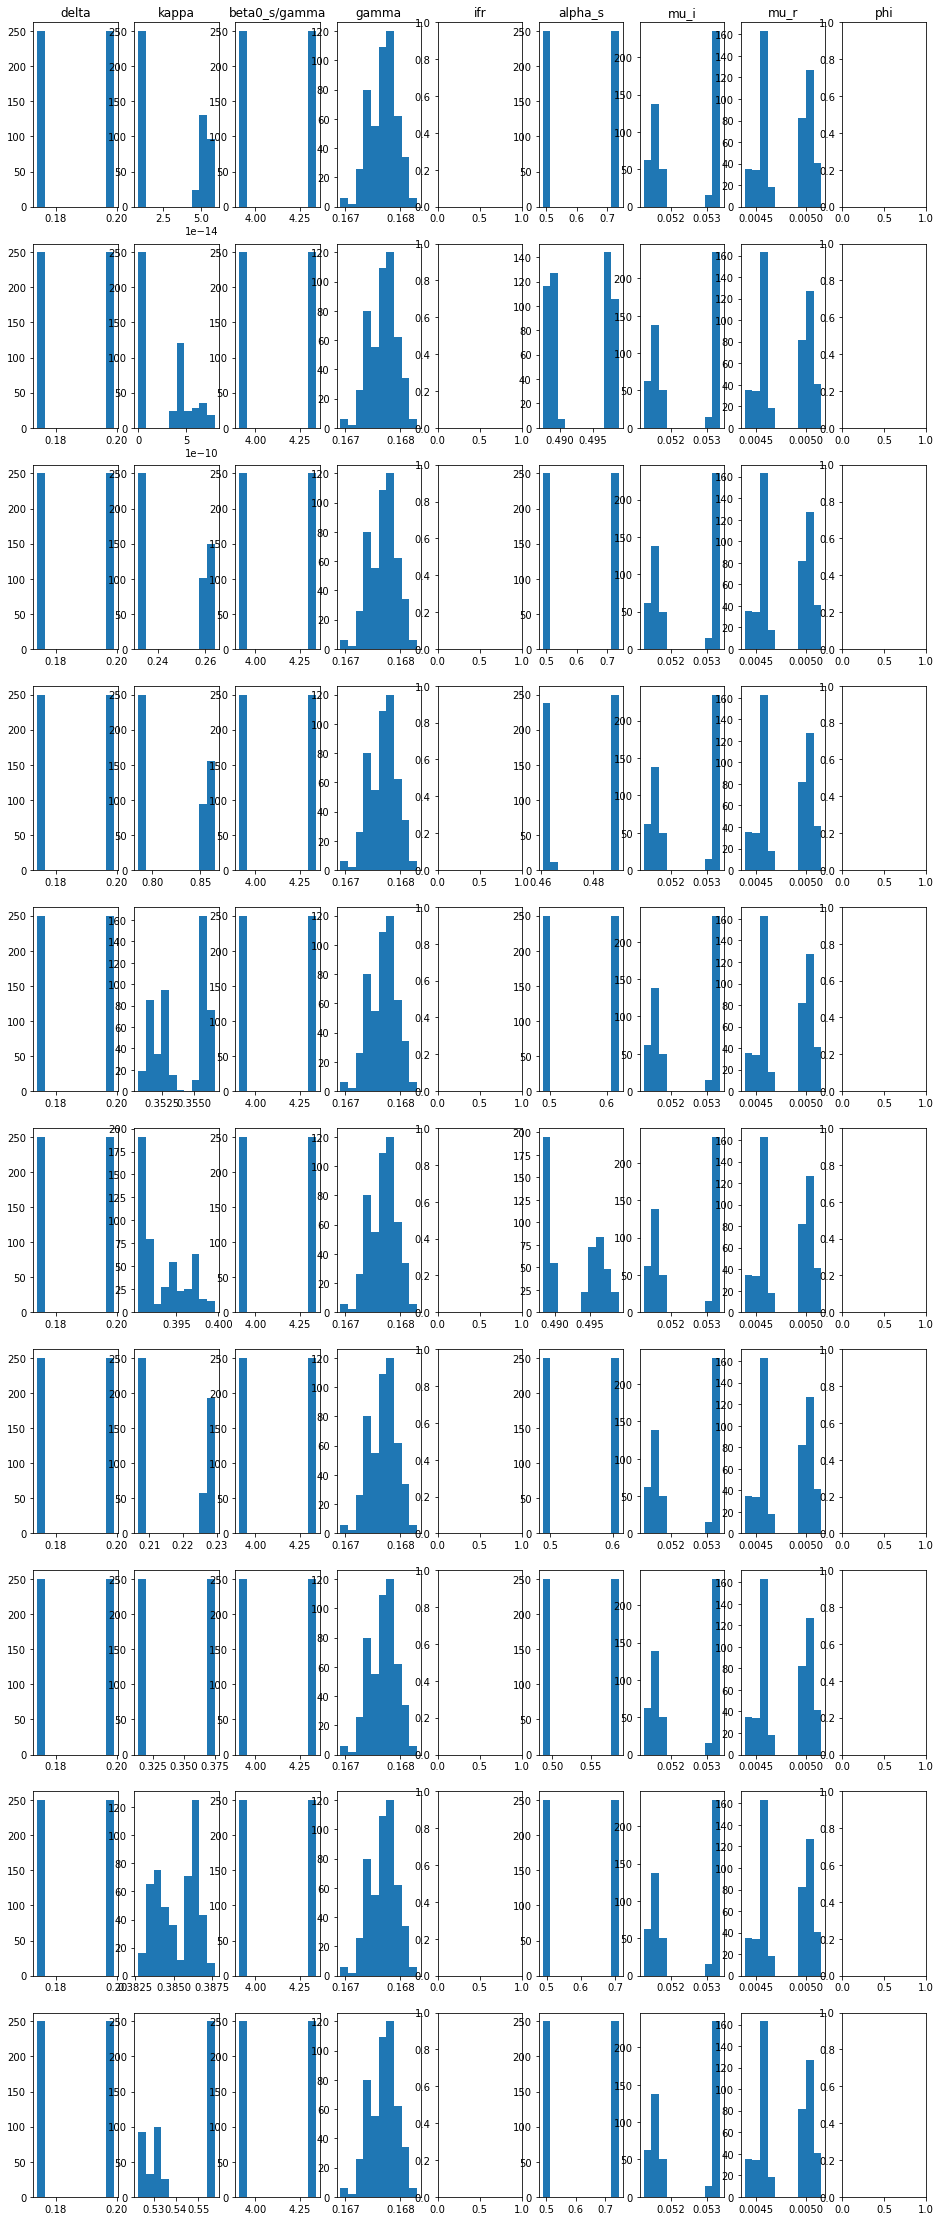

In [206]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=num_states+(num_states==1), ncols=9, figsize=(16,4*s))

axs[0,0].set_title('delta');
axs[0,1].set_title('kappa');
axs[0,2].set_title('beta0_s/gamma');
axs[0,3].set_title('gamma');
axs[0,4].set_title('ifr');
axs[0,5].set_title('alpha_s');
axs[0,6].set_title('mu_i');
axs[0,7].set_title('mu_r');
axs[0,8].set_title('phi');

for j in range(num_states):
    #axs[j,0].hist(df["delta." + str(j+1)]);
    axs[j,0].hist(df["delta"]);
    axs[j,1].hist(df["kappa." + str(j+1)]); 
    #axs[j,2].hist(df["beta0_s." + str(j+1)]/df["gamma." + str(j+1)]);   
    axs[j,2].hist(df["beta0_s." + str(j+1)]/df["gamma"]); 
    #axs[j,3].hist(df["gamma." + str(j+1)]); 
    axs[j,3].hist(df["gamma"]); 
    #axs[j,4].hist(df["ifr"]); 
    axs[j,5].hist(df["alpha_s." + str(j+1)]); 
    #axs[j,6].hist(df["mu_i." + str(j+1)]); 
    #axs[j,7].hist(df["mu_r." + str(j+1)]); 
    axs[j,6].hist(df["mu_i"]); 
    axs[j,7].hist(df["mu_r"]);     
    #axs[j,6].hist(df["mu"]); 
    #axs[j,8].hist(df["phi." + str(j+1)]); 

plt.show()

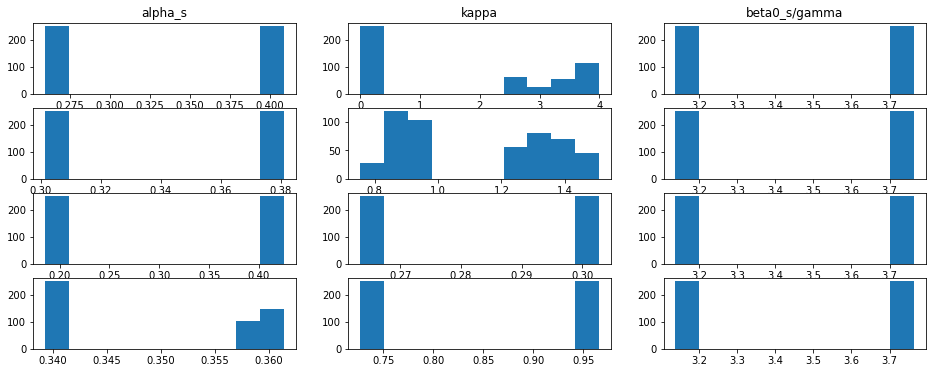

In [139]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=num_states+(num_states==1), ncols=3, figsize=(16,6))

axs[0,0].set_title('alpha_s');
axs[0,1].set_title('kappa');
axs[0,2].set_title('beta0_s/gamma');
#axs[0,3].set_title('sigma');
#axs[0,4].set_title('phi');

for j in range(num_states):
    axs[j,0].hist(df["alpha_s." + str(j+1)]);
    axs[j,1].hist(df["kappa." + str(j+1)]); 
    axs[j,2].hist(df["beta0_s." + str(j+1)]/df["gamma"]);     
    #axs[j,3].hist(df["sigma." + str(j+1)]); 
    #axs[j,4].hist(df["phi." + str(j+1)]); 

plt.show()

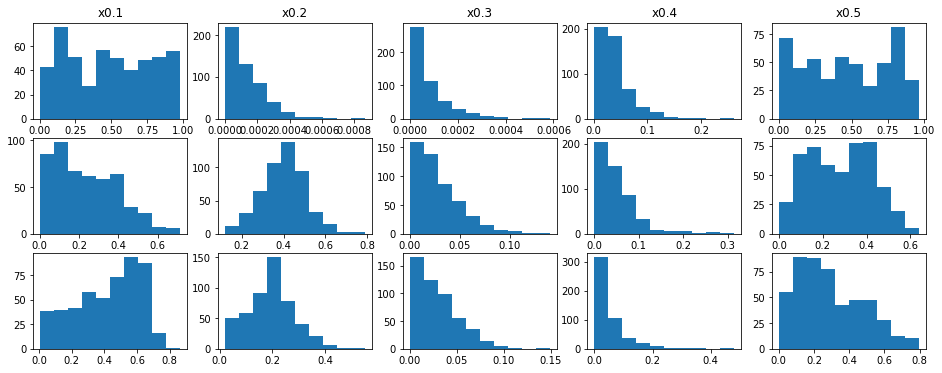

In [72]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=num_states+(num_states==1), ncols=n_compartments, figsize=(16,2*s))

for i in range(n_compartments):
    axs[0,i].set_title('x0.' + str(i+1));
    
    for j in range(num_states):
        axs[j,i].hist(df["x0." + str(j+1) + "." + str(i+1)]); 

plt.show()

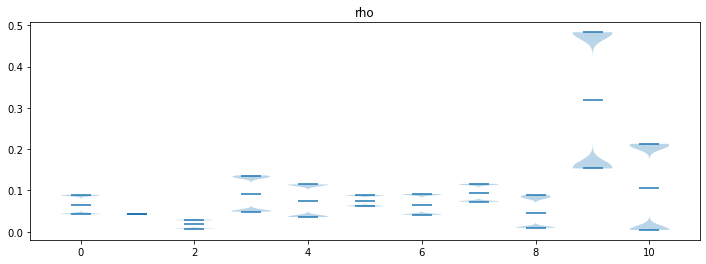

In [201]:
# violin plots
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,4))

ax.violinplot(dataset=[df["rho." + str(npi+1)] for npi in range(p)],
                     positions=np.arange(p), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
ax.set_title('rho', fontsize=fs)

#plt.savefig("beta_lmm_normal_scale_simplex_rho_s_violins.pdf")
plt.show()

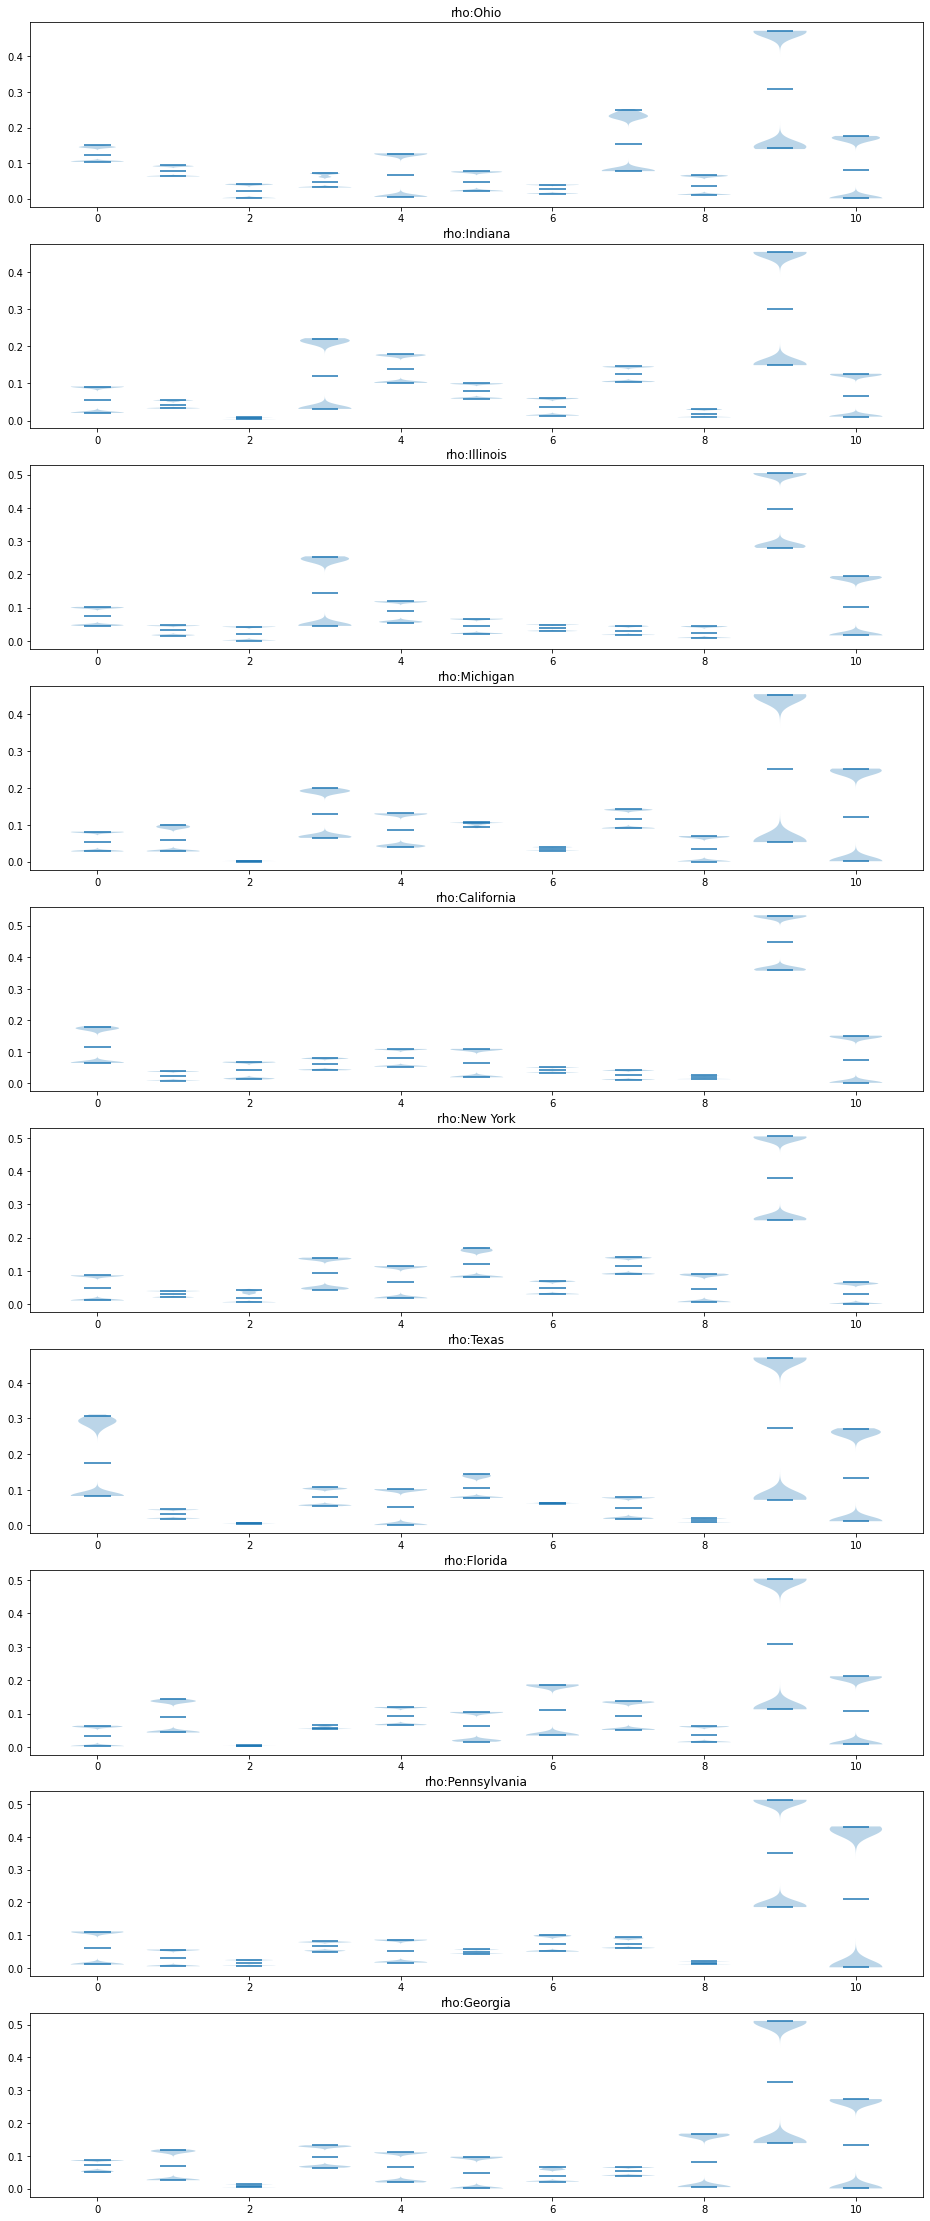

In [202]:
# violin plots
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=num_states+(num_states==1), ncols=1, figsize=(16,4*s))
axs[0].set_title('rho', fontsize=fs)

for j in range(num_states):
    axs[j].set_title("rho:" + states_to_model[j], fontsize=fs)    
    axs[j].violinplot(dataset=[df["rho_s." + str(j+1) + "." + str(npi+1)] for npi in range(p)],
                         positions=np.arange(p), points=300, widths=0.7, vert=True,
                         showmeans=False, showextrema=False, showmedians=True,
                         quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)

#plt.savefig("beta_lmm_normal_scale_simplex_rho_s_violins.pdf")
plt.show()

In [203]:
# import datetime as dt

# x = [dt.datetime.strptime(d,'%Y%m%d').date() for d in dates.astype(str)]

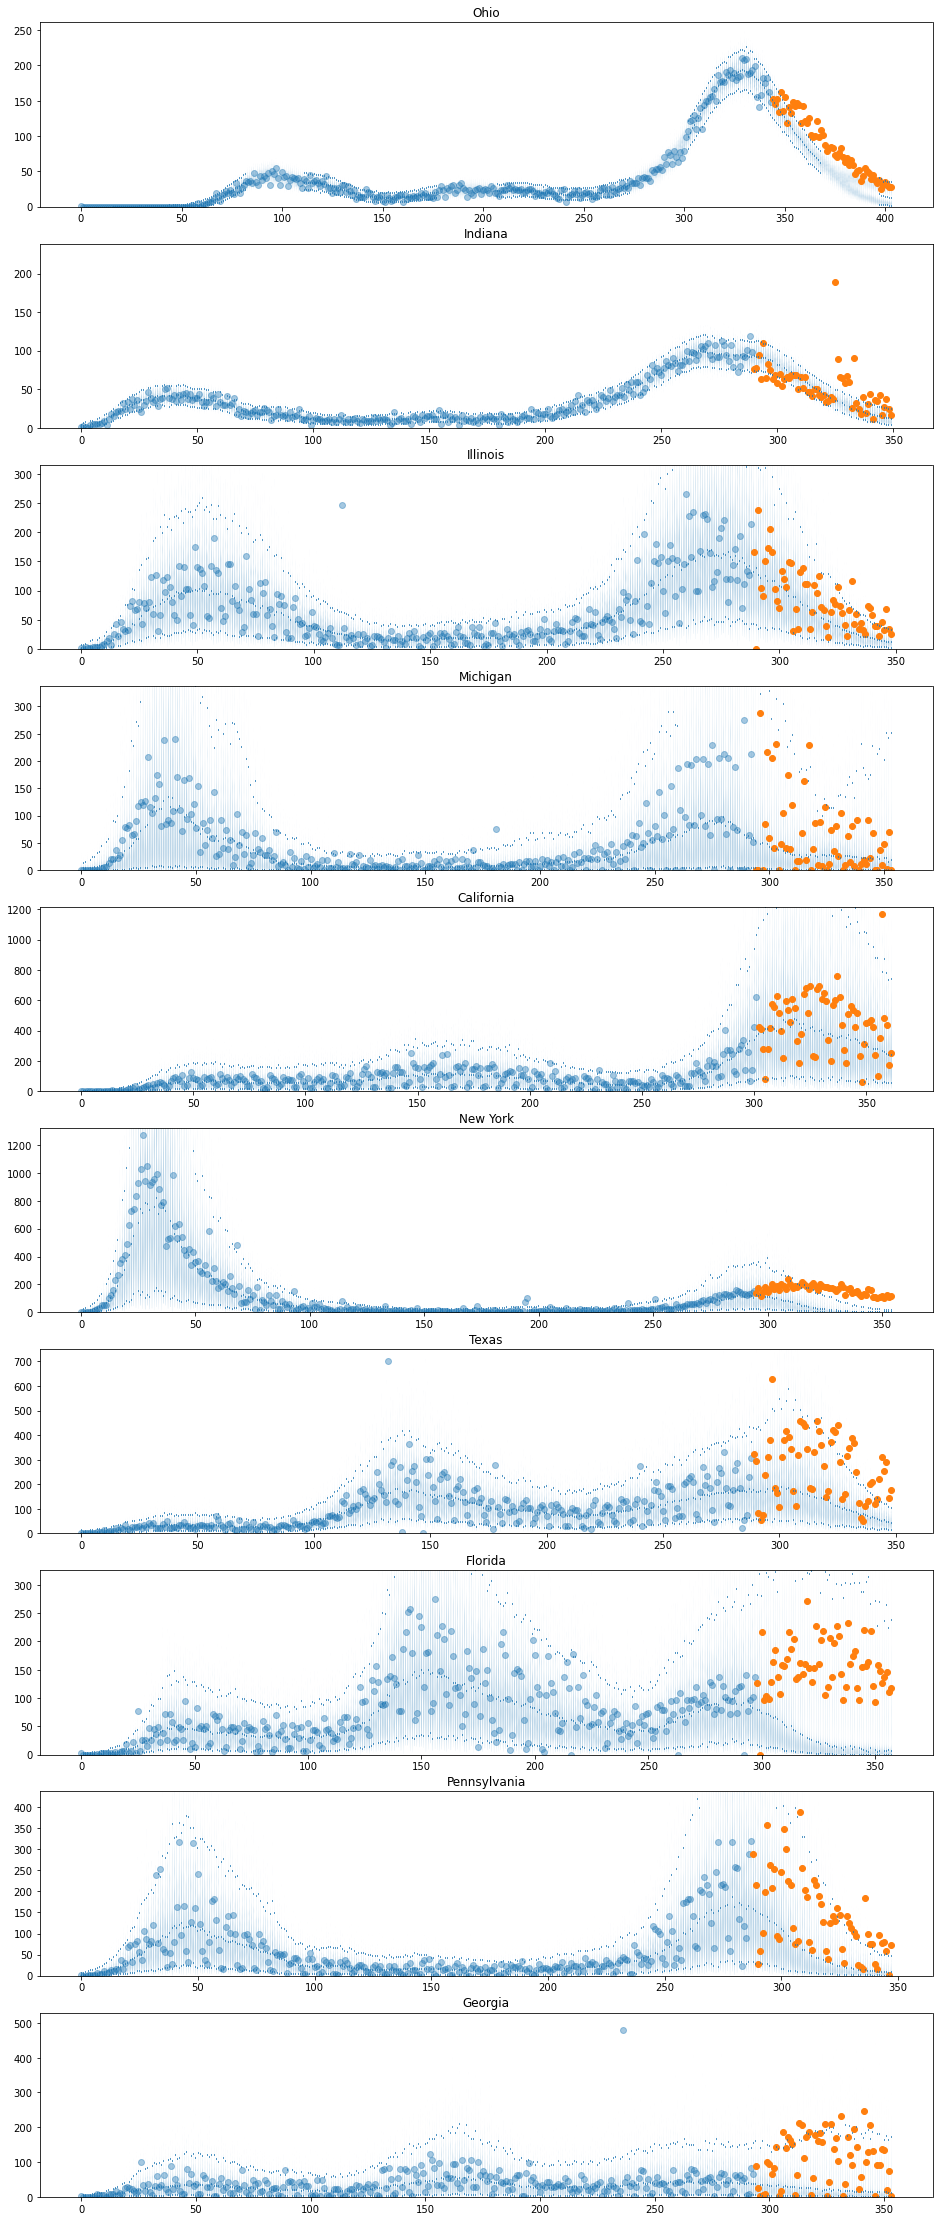

In [204]:
# posterior predictive distribution on deaths
fs = 12  # fontsize
fig, ax = plt.subplots(nrows=num_states+(num_states==1), ncols=1, figsize=(16,4*s))

for j in range(num_states):
    ax[j].set_title(states_to_model[j], fontsize=fs)
    ax[j].violinplot(dataset=[df["dhat." + str(day+1)] for day in range(t_npi[j],t_npi[j+1])],
                         positions=np.arange(t_npi[j+1]-t_npi[j]), points=100, widths=0.7, vert=True,
                         showmeans=False, showextrema=False, showmedians=True,
                         quantiles=[[0.025, 0.975] for day in range(t_npi[j],t_npi[j+1])], bw_method=0.1)
    ax[j].scatter(np.arange(days_d[j]),d[t_d[j]:t_d[j+1]], alpha = 0.4)
    ax[j].scatter(np.arange(days_d[j],days_d[j]+t_pred),d_pred[t_pred*j:(t_pred*(j+1))])
    ax[j].set_ylim(0,50+np.max([np.max(d_pred[t_pred*j:(t_pred*(j+1))]),np.max(d[t_d[j]:t_d[j+1]])]))
    #ax[j].set_ylim([0,10])

KeyError: 'beta_eps.1'

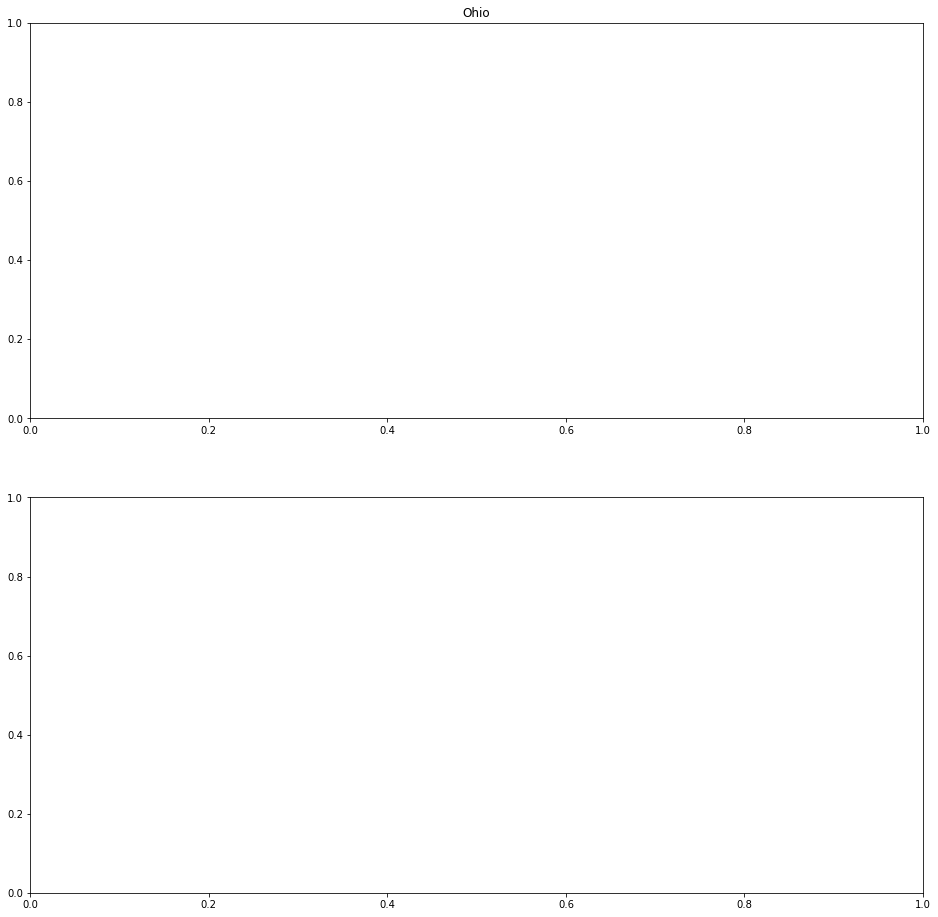

In [522]:
fs = 12  # fontsize
fig, ax = plt.subplots(nrows=num_states+(num_states==1), ncols=1, figsize=(16,16))

for j in range(num_states):
    ax[j].set_title(states_to_model[j], fontsize=fs)
    ax[j].violinplot(dataset=[df["beta_eps." + str(day+1)] for day in range(t_npi[j],t_npi[j+1])],
                         positions=np.arange(t_npi[j+1]-t_npi[j]), points=100, widths=0.7, vert=True,
                         showmeans=False, showextrema=False, showmedians=True,
                         quantiles=[[0.025, 0.975] for day in range(t_npi[j],t_npi[j+1])], bw_method=0.1)

In [165]:
# save estimates

In [166]:
df.to_pickle("bhm_est.pkl")

## One state (ohio)

In [16]:
t = 365 # days to model

tf = 731
s = len(states)

gamma = 0.15
lag = 28

cutoff = 40
tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 28, 3))
tau_rev = tau_rev/np.sum(tau_rev)

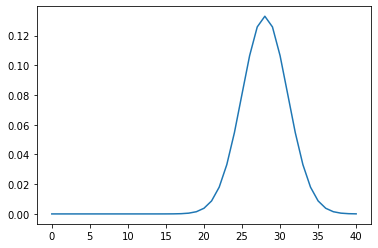

In [17]:
plt.plot(np.flip(tau_rev))

In [18]:
num_states = 1 #51
starts = np.zeros(num_states)
n = np.zeros(num_states)
days = np.zeros(num_states)

state = states[35]; print(state)
    
n = get_state_pop(pops,state)
    
state_data = get_state_data(data,state)
u, _ = clean_npis(state_data,tf)
d = clean_deaths(state_data,tf)
    
#start = np.min(np.where(d > 50))
start = np.min(np.where(d > 1))
if start <= cutoff:
    start = 0
else: 
    start = start - cutoff
days = t-start

d_full = d

#u = u[start:t,]
# remove int'l travel controls
u = u[start:t,[0,1,2,3,4,5,6,8,9,10,11]]
d = d[start:t]

p = np.shape(u)[1]

Ohio


In [19]:
start

36

In [20]:
print(np.shape(u));
print(np.shape(d));
#ts = np.cumsum(np.concatenate([np.array([0]),days])); print(ts)
ts = days; print(ts)
print(n)

(329, 11)
(329,)
329
[11594163.]


## Multiplicative control model

In [633]:
sir_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> t;         // days
  array[t] int d;    // deaths
  matrix[t,p] u;  // NPIs  
  int<lower=1> n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
  
}
parameters {
  real<lower=0> beta0;   
  //vector<lower=0>[t] beta;
  
  //vector<lower=0>[t] beta0t; // AR(1) process for beta0
  vector[t] beta_eps;
  
  real<lower=0> sigma; // beta_eps std dev
  //real<lower=0> c; // bias
  real<lower=0,upper=1> phi; //autocorrelation
  
  vector[p] rho; // npi effects
  
  //real<lower=0> kappa; // over-dispersion parameters
  
  real<lower=0> gamma;  
  real<lower=0> ifr;
  
  //real s0_tilde; 
  simplex[3] x0; // initial state
}
transformed parameters {
  //matrix[t+1,2] x;  // SIR state 
  vector<lower=0,upper=1>[t+1] sus; // proportion susceptible
  vector<lower=0,upper=1>[t+1] inf; // proportion infected
  
  vector<lower=0,upper=1>[t] nu;  // new infections
  vector<lower=0>[t] death_par;  // death mean
  
  vector<lower=0>[t] beta;
  
  //real<lower=0,upper=1> s0 = 0.999 + 0.001 * Phi(s0_tilde);  // initial susceptible 
  
  //real log_beta0 = log(beta0);
  //vector[t] log_beta = log_beta0 + u * rho + beta_eps;
  //vector<lower=0>[t] beta = exp(log_beta);
  
  //x[1,1] = s0;
  //x[1,2] = 1-s0;
  //sus[1] = x0[1];
  //inf[1] = x0[2];  
  sus[1] = 0.0001 * x0[1] + 0.9999;
  inf[1] = 0.0001 * x0[2];
  //sus[1] = s0;
  //inf[1] = 1-s0;
  for(day in 1:t){
    beta[day] = beta0 * prod(1 - rho' .* u[day]) + beta_eps[day];
  
    //nu[day] = beta[day] * x[day,1] * x[day,2];
    //x[day+1,1] = x[day,1] - nu[day];
    //x[day+1,2] = x[day,2]*(1-gamma) + nu[day];
    nu[day] = beta[day] * sus[day] * inf[day];
    sus[day+1] = sus[day] - nu[day];
    inf[day+1] = inf[day]*(1-gamma) + nu[day];
    if(day <= cutoff){
      death_par[day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[1:day]);
      //death_par[day] = sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day]);      
      death_par[day] += sum(tau_rev[1:(cutoff-day+1)]) * (1-sus[1]);
      death_par[day] *= ifr * n;
      //death_par[day] = n*ifr*(sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day])+sum(tau_rev[1:(cutoff-day+1)])*(1-sus[1]));
    }else{
      death_par[day] = n * ifr * dot_product(tau_rev, nu[(day-cutoff):day]);
      //death_par[day] = n * ifr * sum(tau_rev .* nu[(day-cutoff):day]);
    }
  }
}  
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15);
  
  //target += normal_lpdf(beta0t[1] | 3 * gamma, 1 * gamma);  
  //target += normal_lpdf(beta0t[2:t] | c + phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas
  //target += normal_lpdf(beta0t[2:t] | phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas  
  //target += normal_lpdf(beta0t[2:t] | beta0t[1:(t-1)], sigma); // SRW model on betas   
  
  target += uniform_lpdf(phi | 0, 1);
  //target += normal_lpdf(beta_eps | 0, sigma);
  target += normal_lpdf(beta_eps[1] | 0, sigma);
  target += normal_lpdf(beta_eps[2:t] | phi * beta_eps[1:(t-1)], sigma); // AR(1) model on beta_eps

  //target += normal_lpdf(rho | 0, 1);
  target += uniform_lpdf(rho | 0, 1);
  
  target += dirichlet_lpdf(x0 | rep_vector(1,3));
  //target += normal_lpdf(s0_tilde | 0, 1);
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  target += normal_lpdf(gamma | 0.15, 0.05);

  //target += neg_binomial_2_lpmf(d | death_par, kappa); // likelihood on deaths
  target += poisson_lpmf(d | death_par);
  
  target += -log(sigma);
  //target += -log(kappa);
  //increment_log_prob(-log(kappa)); // "Jeffreys" prior on scale parameter  
}
generated quantities {
    //array[t] int dhat = neg_binomial_2_rng(death_par, kappa);
    array[t] int dhat = poisson_rng(death_par);
}
"""

sir_data = {"p" : p, "t" : ts, 
            "d" : d.astype(int), "u" : u, "n" : int(n),
            "cutoff" : cutoff, "tau_rev" : tau_rev
           }

In [634]:
posterior = stan.build(sir_code, data=sir_data)

Building...



Building: 34.1s, done.Messages from stanc:


In [660]:
# prod model: (1-rho * u)
fit = posterior.sample(num_chains=2, num_samples=1000, num_warmup = 3000, save_warmup = False,
                       init=[{"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09}])

Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   1% (101/8000)
Sampling:   2% (200/8000)
Sampling:   4% (300/8000)
Sampling:   5% (400/8000)
Sampling:   6% (500/8000)
Sampling:   8% (600/8000)
Sampling:   9% (700/8000)
Sampling:  10% (800/8000)
Sampling:  11% (900/8000)
Sampling:  12% (1000/8000)
Sampling:  14% (1100/8000)
Sampling:  15% (1200/8000)
Sampling:  16% (1300/8000)
Sampling:  18% (1400/8000)
Sampling:  19% (1500/8000)
Sampling:  20% (1600/8000)
Sampling:  21% (1700/8000)
Sampling:  22% (1800/8000)
Sampling:  24% (1900/8000)
Sampling:  25% (2000/8000)
Sampling:  26% (2100/8000)
Sampling:  28% (2200/8000)
Sampling:  29% (2300/8000)
Sampling:  30% (2400/8000)
Sampling:  31% (2500/8000)
Sampling:  32% (2600/8000)
Sampling:  34% (2700/8000)
Sampling:  35% (2800/8000)
Sampling:  36% (2900/8000)
Sampling:  38% (3000/8000)
Sampling:  39% (3100/8000)
Sampling:  40% (3200/8000)
Sampling:  41% (3300/8000)
Sampling:  42% (3400/8000)
Sampling:  44% (3500/8000)
S

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: beta[1] is -90371.4, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 42, column 2 to column 26)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: beta[1] is -2581.79, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[94] is -1.21261e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::lo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[93] is -2.16869e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::lo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[104] is -5.74178e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::l

...

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[155] is -1.51722e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[93] is -2.707e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpst

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[112] is -3.39169e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::l

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[163] is -5.28971e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::l

  Exception: model_l7dz7e3o_namespace::log_prob: nu[108] is -6.03908e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[108] is -3.48183e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this 

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[164] is -1.54325e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.


In [613]:
# mult model: log linear
fit = posterior.sample(num_chains=2, num_samples=1000, num_warmup = 1000, save_warmup = False,
                       init=[{"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.zeros(p), "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.zeros(p), "sigma": 0.09}])

Sampling:   0%
Sampling:   0% (1/4000)
Sampling:   0% (2/4000)
Sampling:   3% (101/4000)
Sampling:   5% (200/4000)
Sampling:   8% (300/4000)
Sampling:  10% (400/4000)
Sampling:  12% (500/4000)
Sampling:  15% (600/4000)
Sampling:  18% (700/4000)
Sampling:  20% (800/4000)
Sampling:  22% (900/4000)
Sampling:  25% (1000/4000)
Sampling:  28% (1100/4000)
Sampling:  30% (1200/4000)
Sampling:  32% (1300/4000)
Sampling:  35% (1400/4000)
Sampling:  38% (1500/4000)
Sampling:  40% (1600/4000)
Sampling:  42% (1700/4000)
Sampling:  45% (1800/4000)
Sampling:  48% (1901/4000)
Sampling:  50% (2001/4000)
Sampling:  50% (2002/4000)
Sampling:  53% (2101/4000)
Sampling:  55% (2200/4000)
Sampling:  58% (2300/4000)
Sampling:  60% (2400/4000)
Sampling:  62% (2500/4000)
Sampling:  65% (2600/4000)
Sampling:  68% (2700/4000)
Sampling:  70% (2800/4000)
Sampling:  72% (2900/4000)
Sampling:  75% (3000/4000)
Sampling:  78% (3100/4000)
Sampling:  80% (3200/4000)
Sampling:  82% (3300/4000)
Sampling:  85% (3400/4000)
S

  Exception: model_gzd3jqvd_namespace::log_prob: sus[3] is nan, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_4w1dilk4/model_gzd3jqvd.stan', line 36, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_gzd3jqvd_namespace::log_prob: sus[3] is nan, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_4w1dilk4/model_gzd3jqvd.stan', line 36, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often

## Additive control model

In [675]:
sir_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> t;         // days
  array[t] int d;    // deaths
  matrix[t,p] u;  // NPIs  
  int<lower=1> n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
  
}
parameters {
  real<lower=0> beta0; 
  //real beta0;
  //real<lower=0,upper=1> beta0;
  //vector<lower=0>[t] beta;
  
  //vector<lower=0>[t] beta0t; // AR(1) process for beta0
  vector[t] beta_eps;
  //vector<lower=0>[t] beta_eps;
  //vector<lower=0,upper=1>[t] beta_eps;
  
  real<lower=0> sigma; // beta_eps std dev
  //real<lower=0> c; // bias
  real<lower=0,upper=1> phi; //autocorrelation
  
  simplex[p] rho; // relative npi effects
  real<lower=0,upper=1> alpha; // total effect
  
  //real<lower=0> kappa; // over-dispersion parameters
  
  real<lower=0> gamma;  
  //real<lower=0.05,upper=0.25> gamma;  
  real<lower=0,upper=1> ifr;
  
  //real s0_tilde; 
  simplex[3] x0; // initial state
}
transformed parameters {
  //matrix[t+1,2] x;  // SIR state 
  vector<lower=0,upper=1>[t+1] sus; // proportion susceptible
  vector<lower=0,upper=1>[t+1] inf; // proportion infected
  
  vector<lower=0,upper=1>[t] nu;  // new infections
  vector<lower=0>[t] death_par;  // death mean
  
  //real<lower=0,upper=1> s0 = 0.999 + 0.001 * Phi(s0_tilde);  // initial susceptible 
  
  //vector[t] beta = beta0 * (1 - alpha * u * rho);  
  //vector<lower=0>[t] beta = beta0 * (1 - alpha * u * rho) + beta_eps; 
  vector[t] beta = beta0 * (1 - alpha * u * rho) + beta_eps;   
  //vector[t] beta = beta0t .* (1 - alpha * u * rho);
  //vector[t] beta = beta0 * (1 - alpha * u * rho) .* beta_eps; 
  //vector[t] log_beta_eps = logit(beta_eps);
  
  //x[1,1] = s0;
  //x[1,2] = 1-s0;
  //sus[1] = x0[1];
  //inf[1] = x0[2];  
  sus[1] = 0.0001 * x0[1] + 0.9999;
  inf[1] = 0.0001 * x0[2];
  //sus[1] = s0;
  //inf[1] = 1-s0;
  for(day in 1:t){
    //nu[day] = beta[day] * x[day,1] * x[day,2];
    //x[day+1,1] = x[day,1] - nu[day];
    //x[day+1,2] = x[day,2]*(1-gamma) + nu[day];
    nu[day] = beta[day] * sus[day] * inf[day];
    sus[day+1] = sus[day] - nu[day];
    inf[day+1] = inf[day]*(1-gamma) + nu[day];
    if(day <= cutoff){
      death_par[day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[1:day]);
      //death_par[day] = sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day]);      
      death_par[day] += sum(tau_rev[1:(cutoff-day+1)]) * (1-sus[1]);
      death_par[day] *= ifr * n;
      //death_par[day] = n*ifr*(sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day])+sum(tau_rev[1:(cutoff-day+1)])*(1-sus[1]));
    }else{
      death_par[day] = n * ifr * dot_product(tau_rev, nu[(day-cutoff):day]);
      //death_par[day] = n * ifr * sum(tau_rev .* nu[(day-cutoff):day]);
    }
  }
}  
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15);
  //target += uniform_lpdf(beta0 | 0, 1);
  //target += normal_lpdf(beta | beta0 * (1 - alpha * u * rho), sigma);
  
  //target += normal_lpdf(beta0t[1] | 3 * gamma, 1 * gamma);  
  //target += normal_lpdf(beta0t[2:t] | c + phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas
  //target += normal_lpdf(beta0t[2:t] | phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas  
  //target += normal_lpdf(beta0t[2:t] | beta0t[1:(t-1)], sigma); // SRW model on betas   
  
  target += uniform_lpdf(phi | 0, 1);
  //target += normal_lpdf(beta_eps | 0, sigma);
  //target += normal_lpdf(beta_eps[1] | 0, gamma);
  target += normal_lpdf(beta_eps[1] | 0, sigma);
  target += normal_lpdf(beta_eps[2:t] | phi * beta_eps[1:(t-1)], sigma); // AR(1) model on beta_eps
  //target += normal_lpdf(log_beta_eps[1] | 0, sigma);
  //target += normal_lpdf(log_beta_eps[2:t] | phi * log_beta_eps[1:(t-1)], sigma); // AR(1) model on log_beta_eps
 
  target += uniform_lpdf(alpha | 0, 1);
  target += dirichlet_lpdf(rho | rep_vector(1, p));
  
  target += dirichlet_lpdf(x0 | rep_vector(1,3));
  //target += normal_lpdf(s0_tilde | 0, 1);
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  target += normal_lpdf(gamma | 0.15, 0.05);
  //target += uniform_lpdf(gamma | 0.05, 0.25);

  //target += neg_binomial_2_lpmf(d | death_par, kappa); // likelihood on deaths
  target += poisson_lpmf(d | death_par);
  
  target += -log(sigma);
  //target += uniform_lpdf(sigma | 0, 0.1);
  //target += -log(kappa);
  //increment_log_prob(-log(kappa)); // "Jeffreys" prior on scale parameter  
}
generated quantities {
    //array[t] int dhat = neg_binomial_2_rng(death_par, kappa);
    array[t] int dhat = poisson_rng(death_par);
}
"""

sir_data = {"p" : p, "t" : ts, 
            "d" : d.astype(int), "u" : u, "n" : int(n),
            "cutoff" : cutoff, "tau_rev" : tau_rev
           }

In [676]:
posterior = stan.build(sir_code, data=sir_data)

Building...



Building: 33.5s, done.Messages from stanc:


In [677]:
fit = posterior.sample(num_chains=3, num_samples=2000, num_warmup = 3000, save_warmup = False,
                       init=[{"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09}])

Sampling:   0%
Sampling:   0% (1/15000)
Sampling:   0% (2/15000)
Sampling:   0% (3/15000)
Sampling:   1% (102/15000)
Sampling:   1% (201/15000)
Sampling:   2% (300/15000)
Sampling:   3% (400/15000)
Sampling:   3% (500/15000)
Sampling:   4% (600/15000)
Sampling:   5% (700/15000)
Sampling:   5% (800/15000)
Sampling:   6% (900/15000)
Sampling:   7% (1000/15000)
Sampling:   7% (1100/15000)
Sampling:   8% (1200/15000)
Sampling:   9% (1300/15000)
Sampling:   9% (1400/15000)
Sampling:  10% (1500/15000)
Sampling:  11% (1600/15000)
Sampling:  11% (1700/15000)
Sampling:  12% (1800/15000)
Sampling:  13% (1900/15000)
Sampling:  13% (2000/15000)
Sampling:  14% (2100/15000)
Sampling:  15% (2200/15000)
Sampling:  15% (2300/15000)
Sampling:  16% (2400/15000)
Sampling:  17% (2500/15000)
Sampling:  17% (2600/15000)
Sampling:  18% (2700/15000)
Sampling:  19% (2800/15000)
Sampling:  19% (2900/15000)
Sampling:  20% (3000/15000)
Sampling:  21% (3100/15000)
Sampling:  21% (3200/15000)
Sampling:  22% (3300/15

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: sus[3] is -3.56323e+07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 42, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: sus[5] is -7269.4, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 42, column 2 to column 35)
  If this warning occurs sporadically, such a

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[152] is -1.1494e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[148] is -3.16387e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/http

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[96] is -1.95482e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::lo

  Exception: model_qvzwz7gn_namespace::log_prob: inf[2] is -5.42192e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 43, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[37] is -9.66227e-12, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this wa

...

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[322] is -9.95955e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[304] is -1.55523e-05, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/htt

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[166] is -2.18798e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::l

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[83] is -4.12792e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::lo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[95] is -2.176e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[108] is -2.94925e-08, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::l

## Plots

In [678]:
az.summary(fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.518,0.062,0.416,0.639,0.003,0.002,402.0,984.0,1.01
beta_eps[0],0.002,0.028,-0.053,0.059,0.001,0.003,669.0,144.0,1.13
beta_eps[1],0.004,0.032,-0.058,0.071,0.001,0.003,482.0,213.0,1.10
beta_eps[2],0.006,0.033,-0.058,0.073,0.001,0.003,477.0,114.0,1.08
beta_eps[3],0.007,0.033,-0.059,0.074,0.002,0.003,371.0,93.0,1.07
...,...,...,...,...,...,...,...,...,...
dhat[324],167.890,14.221,140.000,193.000,0.196,0.139,5283.0,5527.0,1.00
dhat[325],166.228,13.746,141.000,192.000,0.182,0.129,5701.0,5400.0,1.00
dhat[326],164.608,13.728,141.000,191.000,0.188,0.133,5295.0,5690.0,1.00
dhat[327],163.534,14.152,139.000,191.000,0.241,0.171,3472.0,5521.0,1.00


(array([637.,  57.,  32.,  48., 139., 107.,  89.,  42.,  17.,   1.]),
 array([1.   , 1.138, 1.276, 1.414, 1.552, 1.69 , 1.828, 1.966, 2.104,
        2.242, 2.38 ]),
 <BarContainer object of 10 artists>)

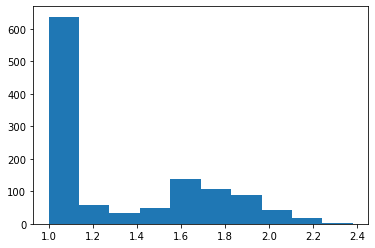

In [661]:
plt.hist(az.summary(fit)['r_hat'])

In [679]:
df = fit.to_frame();
df

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,beta0,beta_eps.1,beta_eps.2,...,dhat.320,dhat.321,dhat.322,dhat.323,dhat.324,dhat.325,dhat.326,dhat.327,dhat.328,dhat.329
draws,,,,,,,,,,,,,,,,,,,,,
0,-25.445475,0.700425,0.001620,10.0,1023.0,0.0,207.975738,0.641331,-0.011766,0.007754,...,180.0,182.0,177.0,180.0,172.0,172.0,153.0,170.0,148.0,159.0
1,-513.438933,0.926809,0.001711,10.0,1023.0,0.0,706.362879,0.493151,0.086859,0.090581,...,193.0,176.0,197.0,161.0,144.0,167.0,157.0,157.0,165.0,142.0
2,-2.617867,0.956796,0.001756,10.0,1023.0,0.0,165.002946,0.465017,-0.001386,0.007166,...,191.0,166.0,164.0,189.0,172.0,191.0,168.0,176.0,163.0,169.0
3,-42.969573,0.813343,0.001620,10.0,1023.0,0.0,197.931489,0.694333,-0.007179,0.020173,...,179.0,173.0,169.0,165.0,155.0,148.0,173.0,158.0,147.0,145.0
4,-522.876857,0.831331,0.001711,10.0,1023.0,0.0,686.757495,0.502615,0.064286,0.128992,...,173.0,176.0,167.0,189.0,167.0,162.0,160.0,163.0,175.0,139.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,142.385271,0.923663,0.001711,10.0,1023.0,0.0,18.644120,0.576839,-0.006055,-0.009117,...,182.0,188.0,188.0,169.0,160.0,173.0,190.0,159.0,165.0,139.0
5996,-103.447471,0.994143,0.001756,10.0,1023.0,0.0,284.530741,0.519482,0.001087,0.009727,...,179.0,214.0,169.0,188.0,171.0,173.0,160.0,190.0,182.0,150.0
5997,126.840313,0.952118,0.001620,10.0,1023.0,0.0,47.390468,0.508377,0.005712,0.011172,...,188.0,192.0,179.0,184.0,182.0,156.0,179.0,158.0,164.0,141.0


In [692]:
# df.to_pickle("control_est_ohio_add_full.pkl")

In [681]:
# df = pd.read_pickle("control_est_ohio.pkl")

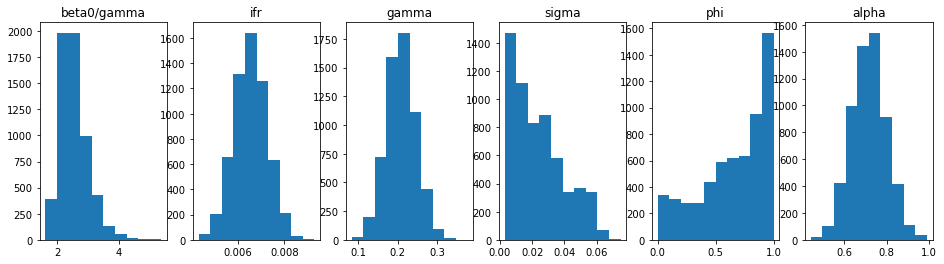

In [682]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(16,4))

axs[0].hist(df["beta0"]/df["gamma"]); axs[0].set_title('beta0/gamma'); 
# axs[0].hist(df["beta0t.1"]/gamma); axs[0].set_title('beta0/gamma'); 
axs[1].hist(df["ifr"]); axs[1].set_title('ifr');
axs[2].hist(df["gamma"]); axs[2].set_title('gamma');
#axs[3].hist(df["s0"]); axs[3].set_title('s0');
# axs[3].hist(df["x0.1"]); axs[3].set_title('x0.1');
# axs[4].hist(df["kappa"]); axs[4].set_title('kappa');
axs[3].hist(df["sigma"]); axs[3].set_title('sigma');
# axs[6].hist(df["c"]); axs[6].set_title('c');
axs[4].hist(df["phi"]); axs[4].set_title('phi');
axs[5].hist(df["alpha"]); axs[5].set_title('alpha');

plt.show()

(array([ 337.,  306.,  281.,  277.,  437.,  592.,  620.,  633.,  950.,
        1567.]),
 array([2.87184023e-04, 1.00172319e-01, 2.00057454e-01, 2.99942589e-01,
        3.99827724e-01, 4.99712859e-01, 5.99597994e-01, 6.99483129e-01,
        7.99368264e-01, 8.99253399e-01, 9.99138534e-01]),
 <BarContainer object of 10 artists>)

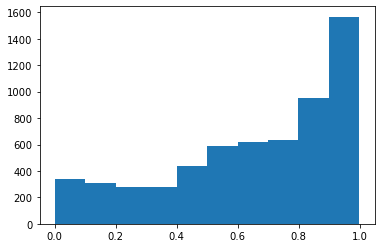

In [683]:
plt.hist(df["phi"])

(array([   4.,    5.,   14.,   52.,  177.,  388., 1037., 1751., 2009.,
         563.]),
 array([0.93611472, 0.9422844 , 0.94845407, 0.95462375, 0.96079343,
        0.96696311, 0.97313278, 0.97930246, 0.98547214, 0.99164181,
        0.99781149]),
 <BarContainer object of 10 artists>)

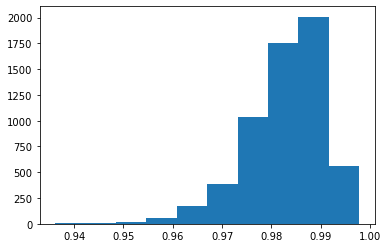

In [684]:
plt.hist(df["x0.1"])

In [685]:
np.mean(df["sigma"])

0.023999741350004357

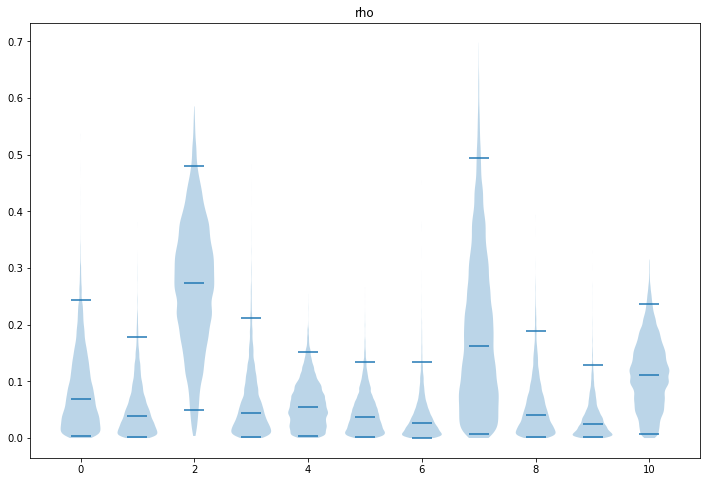

In [686]:
# violin plots
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["rho." + str(npi+1)] for npi in range(p)],
                     positions=np.arange(p), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
ax.set_title('rho', fontsize=fs)

#plt.savefig("beta_lmm_normal_scale_simplex_rho_s_violins.pdf")
plt.show()

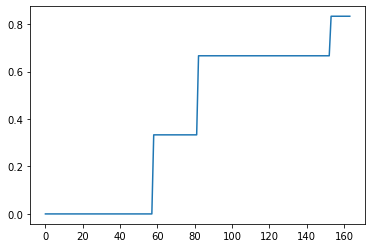

In [657]:
plt.plot(u[:,10])

Text(0.5, 1.0, 'nu')

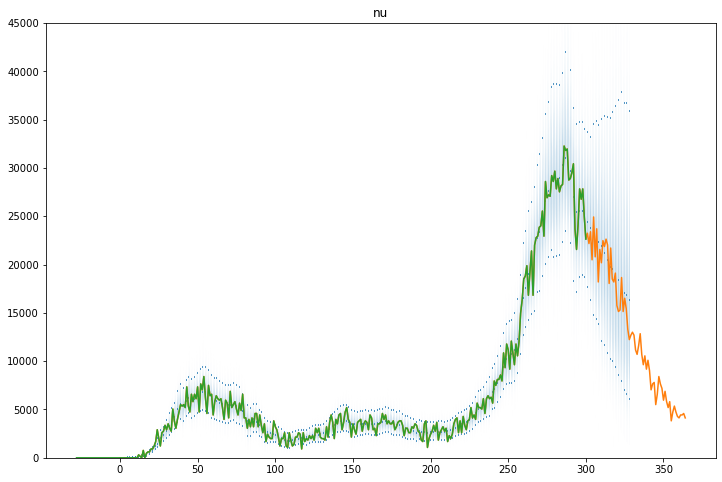

In [689]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[n*df["nu." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
ax.set_ylim([0,45000])
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
ax.plot(d_full[(lag+start):(t+start+lag)]/np.median(df['ifr']))
ax.plot(range(-lag,t-lag-start,1),d/np.median(df['ifr']))
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('nu', fontsize=fs)

Text(0.5, 1.0, 'deaths')

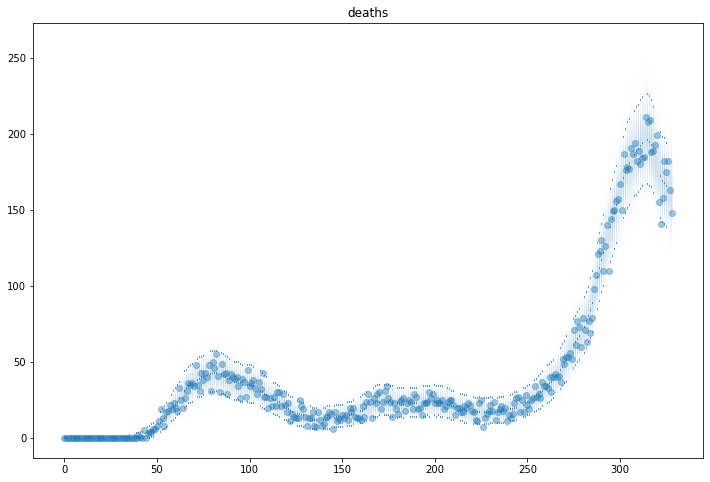

In [694]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["dhat." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.plot(d_full[(lag):(t+lag)])
ax.scatter(range(0,np.shape(d)[0],1),d, alpha = 0.4)
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('deaths', fontsize=fs)

Text(0.5, 1.0, 'beta_eps')

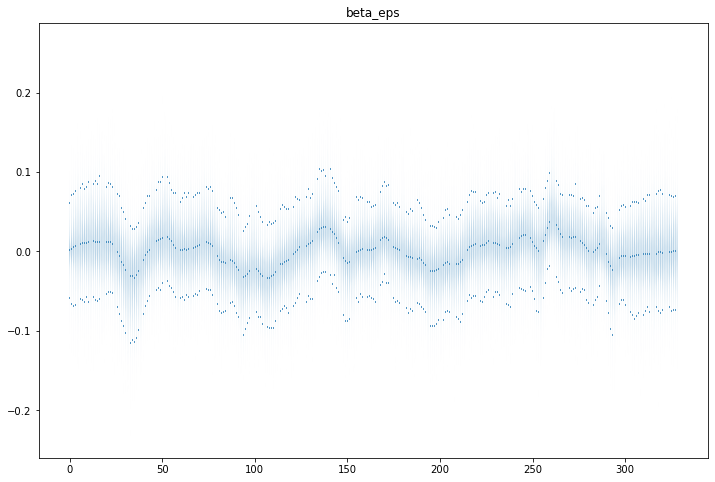

In [691]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["beta_eps." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('beta_eps', fontsize=fs)

## Calculate costs and OC

### Calculate cost incurred by actual policy

In [167]:
# load in data
df = pd.read_pickle('bhm_est.pkl')

In [168]:
df.head()

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,beta0,beta_sd,beta_diff.1,...,dhat.806,dhat.807,dhat.808,dhat.809,dhat.810,dhat.811,dhat.812,dhat.813,dhat.814,dhat.815
draws,,,,,,,,,,,,,,,,,,,,,
0,-2016.496726,0.989736,0.002516,10.0,1023.0,0.0,2030.853382,0.411417,5.675474e-10,-0.464244,...,44.0,45.0,46.0,30.0,33.0,32.0,57.0,47.0,35.0,40.0
1,-2003.135543,0.995357,0.000636,10.0,1023.0,0.0,2019.540859,0.450306,1.114698e-01,-1.009374,...,41.0,33.0,29.0,20.0,25.0,30.0,44.0,42.0,39.0,27.0
2,-2008.201928,0.970365,0.002516,10.0,1023.0,0.0,2040.349478,0.389012,1.863889e-11,-0.524154,...,45.0,53.0,44.0,43.0,49.0,50.0,35.0,55.0,38.0,40.0
3,-2001.559613,0.944134,0.000636,10.0,1023.0,0.0,2026.897592,0.448658,1.170847e-01,-0.836603,...,37.0,37.0,32.0,36.0,33.0,34.0,30.0,28.0,35.0,35.0
4,-2012.528505,0.874266,0.002516,10.0,1023.0,0.0,2033.719673,0.384953,8.658945e-11,0.568557,...,37.0,56.0,41.0,42.0,32.0,25.0,32.0,36.0,40.0,30.0


In [169]:
df.shape

(500, 4958)

In [170]:
df.columns[0:100]

Index(['lp__', 'accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__',
       'divergent__', 'energy__', 'beta0', 'beta_sd', 'beta_diff.1',
       'beta_diff.2', 'rho.1', 'rho.2', 'rho.3', 'rho.4', 'rho.5', 'rho.6',
       'rho.7', 'rho.8', 'rho.9', 'rho.10', 'rho.11', 'rho.12', 'rho_s.1.1',
       'rho_s.2.1', 'rho_s.1.2', 'rho_s.2.2', 'rho_s.1.3', 'rho_s.2.3',
       'rho_s.1.4', 'rho_s.2.4', 'rho_s.1.5', 'rho_s.2.5', 'rho_s.1.6',
       'rho_s.2.6', 'rho_s.1.7', 'rho_s.2.7', 'rho_s.1.8', 'rho_s.2.8',
       'rho_s.1.9', 'rho_s.2.9', 'rho_s.1.10', 'rho_s.2.10', 'rho_s.1.11',
       'rho_s.2.11', 'rho_s.1.12', 'rho_s.2.12', 'rho_scale', 'alpha',
       'alpha_s.1', 'alpha_s.2', 'alpha_scale', 'kappa.1', 'kappa.2', 'gamma',
       'ifr', 'x0.1.1', 'x0.2.1', 'x0.1.2', 'x0.2.2', 'x0.1.3', 'x0.2.3',
       'beta.1', 'beta.2', 'beta.3', 'beta.4', 'beta.5', 'beta.6', 'beta.7',
       'beta.8', 'beta.9', 'beta.10', 'beta.11', 'beta.12', 'beta.13',
       'beta.14', 'beta.15', 'beta.16'

In [171]:
# set time frame to look at
t0 = 275 - start # october 1, 2020
t1 = 305 - start # october 31, 2020
days = range(t0,t1,1)

In [172]:
print(t_d); print(t_npi)

[  0 365 695]
[  0 425 815]


In [173]:
len(d); u.shape[0]

815

In [244]:
t0 = t_d[1] - 30
t1 = t0 + 30
days = range(t0,t1,1); print(len(days)); print(list(days))

30
[335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364]


In [247]:
# set cost vector
#c = np.ones(p)/(10**6)
c = np.ones(p)*10/n[0]

In [248]:
n

array([11594163.,  6596855.])

In [249]:
df['nu.815']

draws
0      0.000490
1      0.000281
2      0.000426
3      0.000305
4      0.000354
         ...   
495    0.000454
496    0.000378
497    0.000431
498    0.000422
499    0.000397
Name: nu.815, Length: 500, dtype: float64

In [406]:
# calculate cost incurred by actual policy
cost = 0
for day in days:
    cost += np.mean(df["nu." + str(day)]) + np.dot(c,u[day,:])
    
print(cost)

0.061408873834451976


In [408]:
# calculate cost incurred by actual policy
nu_cost = 0
for j in range(df.shape[0]):
    nu_cost += np.sum([df["nu." + str(day)][j] for day in days])/df.shape[0]

u_cost = 0
for day in days:
    u_cost += np.dot(c,u[day,:])
    
print(nu_cost+u_cost)
print(nu_cost)
print(u_cost)

0.061408873834451996
0.06117599803306815
0.0002328758013838514


In [390]:
cost_actual = cost; cost_actual

0.061408873834451976

### Calculate myopic OC

In [252]:
def generate_binary_strings(bit_count):
    binary_strings = []
    def genbin(n, bs=''):
        if len(bs) == 2*n:
            binary_strings.append(bs)           
        else:
            genbin(n, bs + '0 ')
            genbin(n, bs + '1 ')


    genbin(bit_count)
    return binary_strings

binstr = generate_binary_strings(p)

In [253]:
plans = np.zeros([2**p,p])
for i in range(2**p):
    plans[i,:] = [int(x) for x in binstr[i].split()]
    
print(plans)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [1. 1. 1. ... 1. 0. 1.]
 [1. 1. 1. ... 1. 1. 0.]
 [1. 1. 1. ... 1. 1. 1.]]


In [254]:
def sir(gamma,beta0,alpha,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    beta = beta0 * (1 - alpha * np.dot(rho,u))
    for j in range(t-1):
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [534]:
def sir_tv(gamma,beta0,alpha,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    for j in range(t-1):
        beta = beta0 * (1 - alpha * np.dot(rho,u[j,:]))
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [255]:
# def seir(gamma,beta0,alpha,rho,s0,i0,t,u):
#     s = np.array([]); i = np.array([]); nu = np.array([])
#     sj = s0; ij = i0;
#     s = np.append(s,sj); i = np.append(i,ij)
#     beta = beta0 * (1 - alpha * np.dot(rho,u))
#     for j in range(t-1):
#         nuj = beta*sj*ij
#         sj = sj - nuj
#         ij = ij*(1-gamma) + nuj
#         s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
#     return s, i, nu

In [633]:
n_days = t1-t0
# n_samples = np.shape(df)[0]
n_samples = 100

In [631]:
# calculate actual cost (other way)
nu_cost = 0
# evolve SIR model under this plan for each posterior sample
for j in range(n_samples):
    _,_, nu = sir_tv(gamma = df["gamma"][j],
                        beta0 = df["beta0_s.1"][j],
                        alpha = df["alpha_s.1"][j],
                        rho = [df["rho_s.1." + str(k+1)][j] for k in range(p)],
                        s0 = df["sus." + str(t0)][j],
                        i0 = df["inf." + str(t0)][j],
                        t = n_days+1,
                        u = u[days,:])
    nu_cost += np.sum(nu)/n_samples

# calculate cost 
u_cost = 0
for day in days:
    u_cost +=  np.dot(c,u[day,:])
    
print(nu_cost+u_cost)
print(nu_cost)
print(u_cost)

ValueError: shapes (12,) and (6,12) not aligned: 12 (dim 0) != 6 (dim 0)

In [628]:
cost_actual

0.061408873834451976

In [634]:
# calculate myopic OC
costs = np.zeros(2**p)

for i in range(2**p):
    if i in [j*(2**p)//32 for j in range(1,32)]: print(100*i/(2**p))
        
    u_prop = plans[i,:]
    
    #nus = np.zeros([n_samples,n_days-1])
    nu_cost = 0
    # evolve SIR model under this plan for each posterior sample
    for j in range(n_samples):
        _,_, nu = sir(gamma = df["gamma"][j],
                            beta0 = df["beta0_s.1"][j],
                            alpha = df["alpha_s.1"][j],
                            rho = [df["rho_s.1." + str(k+1)][j] for k in range(p)],
                            s0 = df["sus." + str(t0)][j],
                            i0 = df["inf." + str(t0)][j],
                            t = n_days+1,
                            u = u_prop)
        nu_cost += np.sum(nu)/n_samples
    
    # calculate cost 
    costs[i] = nu_cost + n_days*np.dot(c,u_prop)

3.125
6.25
9.375
12.5
15.625
18.75
21.875
25.0
28.125
31.25
34.375
37.5
40.625
43.75
46.875
50.0
53.125
56.25
59.375
62.5
65.625
68.75
71.875
75.0
78.125
81.25
84.375
87.5
90.625
93.75
96.875


In [637]:
np.argmin(costs)

4095

In [638]:
np.min(costs)

0.016559873539001884

In [639]:
np.max(costs)

0.5902502101569581

In [640]:
cost_actual

0.061408873834451976

In [641]:
costs[np.argmin(costs)]

0.016559873539001884

In [642]:
uhat = plans[np.argmin(costs),:]
print(uhat)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [284]:
[round(np.mean(df['rho_s.1.' + str(j+1)]),3) for j in range(p)]

[0.3,
 0.043,
 0.077,
 0.004,
 0.012,
 0.157,
 0.001,
 0.121,
 0.003,
 0.006,
 0.166,
 0.109]

In [643]:
# plot trajectory under myopic OC
nu_opt = np.zeros([n_samples,n_days])
# evolve SIR model under this plan for each posterior sample
for j in range(n_samples):
    _,_, nu_opt[j,:] = sir_tv(gamma = df["gamma"][j],
                        beta0 = df["beta0_s.1"][j],
                        alpha = df["alpha_s.1"][j],
                        rho = [df["rho_s.1." + str(k+1)][j] for k in range(p)],
                        s0 = df["sus." + str(t0)][j],
                        i0 = df["inf." + str(t0)][j],
                        t = n_days+1,
                        u = np.tile(uhat,n_days))

In [543]:
# plot trajectory under myopic OC
nu_actual = np.zeros([n_samples,n_days])
# evolve SIR model under this plan for each posterior sample
for j in range(n_samples):
    _,_, nu_actual[j,:] = sir_tv(gamma = df["gamma"][j],
                        beta0 = df["beta0_s.1"][j],
                        alpha = df["alpha_s.1"][j],
                        rho = [df["rho_s.1." + str(k+1)][j] for k in range(p)],
                        s0 = df["sus." + str(t0)][j],
                        i0 = df["inf." + str(t0)][j],
                        t = n_days+1,
                        u = u[days,:].reshape([n_days*p,]))#u[days,:])

In [644]:
nu_actual_int = np.zeros([n_days,3])
nu_actual_int2 = np.zeros([n_days,3])
nu_opt_int = np.zeros([n_days,3])

for j in range(n_days):
    nu_opt_int[j,:] = np.percentile(nu_opt[:,j],q = [0.025,0.5,0.975])
    nu_actual_int[j,:] = np.percentile(df['nu.' + str(days[j])],q = [0.025,0.5,0.975])
    nu_actual_int2[j,:] = np.percentile(nu_actual[:,j],q = [0.025,0.5,0.975])

In [545]:
print(nu_actual_int); print(nu_actual_int2)

[[0.00169706 0.00172481 0.00176307]
 [0.00168283 0.00171064 0.00175308]
 [0.00166135 0.00169995 0.00173763]
 [0.0016396  0.00168893 0.0017189 ]
 [0.00161762 0.00167131 0.00170153]
 [0.00159545 0.00165237 0.00168411]
 [0.0015731  0.00163295 0.00166575]
 [0.00155059 0.00161316 0.0016465 ]
 [0.00152796 0.00159214 0.00162727]
 [0.00150523 0.00156587 0.00160918]
 [0.00148184 0.0015418  0.00159149]
 [0.00145788 0.00151969 0.00157756]
 [0.0014339  0.00149748 0.00155572]
 [0.00140992 0.00147519 0.00153142]
 [0.00138595 0.00145284 0.00151032]
 [0.00136202 0.00143044 0.00148202]
 [0.00133814 0.00140803 0.00145311]
 [0.00131434 0.0013856  0.0014243 ]
 [0.00128766 0.00136319 0.00139562]
 [0.00126059 0.00134081 0.0013671 ]
 [0.00123372 0.00131848 0.00133875]
 [0.00120707 0.00129541 0.00131081]
 [0.00118066 0.00127112 0.00128344]
 [0.00115452 0.00124526 0.00125675]
 [0.00112864 0.00121962 0.0012329 ]
 [0.00110306 0.00119411 0.00121176]
 [0.00107778 0.00116721 0.00119118]
 [0.00105281 0.00114062 0.00

Text(0.5, 1.0, 'New infections on each day in Ohio in December')

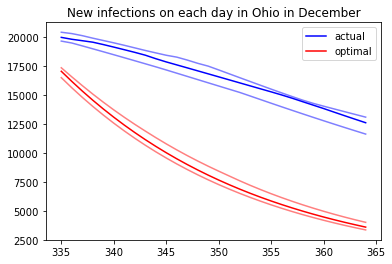

In [546]:
for j in range(3):
    if j == 1:
        plt.plot(days,n[0]*nu_actual_int[:,j], color = 'blue', label = 'actual')
        #plt.plot(n[0]*nu_actual_int2[:,j], 'b--', label = 'actual2')
        plt.plot(days,n[0]*nu_opt_int[:,j], color = 'red', label = 'optimal')
    else:
        plt.plot(days,n[0]*nu_actual_int[:,j], color = 'blue', alpha = 0.5)
        #plt.plot(n[0]*nu_actual_int2[:,j], 'b--', alpha = 0.5)
        plt.plot(days,n[0]*nu_opt_int[:,j], color = 'red', alpha = 0.5)       
    
plt.legend()
plt.title('New infections on each day in Ohio in December')

Text(0.5, 1.0, 'nu')

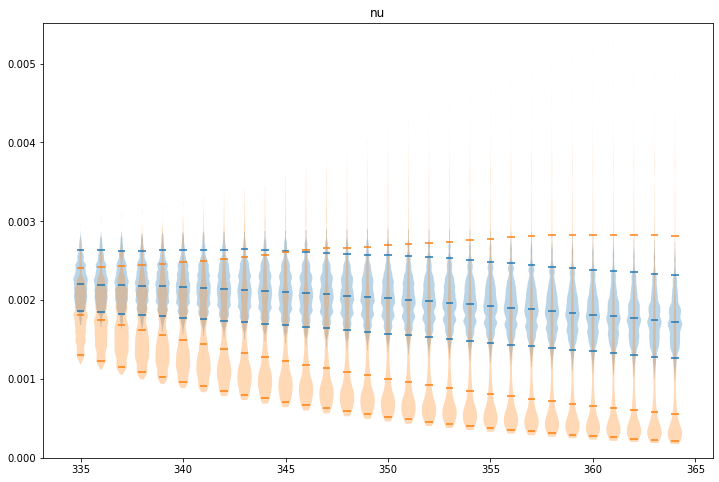

In [323]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["nu." + str(day+1)] for day in days],
                     positions=list(days), points=100, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.05, 0.95] for day in days], bw_method=0.1)
ax.violinplot(dataset=nus,
                     positions=days, points=100, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.05, 0.95] for day in days], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
ax.set_ylim([0,np.max(nus)])
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
#ax.plot(d_full[(lag+start):(t+start+lag)]/np.median(df['ifr']))
#ax.plot(range(-lag,t-lag-start,1),d/np.median(df['ifr']))
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
#ax.legend()
ax.set_title('nu', fontsize=fs)

### Calculate true OC

In [606]:
t0 = 335
gamma = np.array(df['gamma'])
beta0 = np.array(df['beta0_s.1'])
alpha = np.array(df['alpha_s.1'])
rho = np.array([df["rho_s.1." + str(k+1)] for k in range(p)]).transpose()
s0 = np.array(df["sus." + str(t0)])
i0 = np.array(df["inf." + str(t0)])
n_days = 30
n_samples = 100

x0 = np.ones(n_days*p)/2

In [607]:
np.array([df["rho_s.1." + str(k+1)] for k in range(p)]).shape

(12, 500)

In [608]:
def sir_tv(gamma,beta0,alpha,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    for j in range(t-1):
        #beta = beta0 * (1 - alpha * np.dot(rho,u[j,:]))
        beta = beta0 * (1 - alpha * np.dot(rho,u[j*p:(j+1)*p]))
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [609]:
# define cost function
def sir_cost(u, gamma, beta0, alpha, rho, s0, i0, n_days, n_samples):
    nu_cost = 0
    # evolve SIR model under this plan for each posterior sample
    for j in range(n_samples):
        _,_, nu = sir_tv(gamma = gamma[j],
                            beta0 = beta0[j],
                            alpha = alpha[j],
                            rho = rho[j,:],
                            s0 = s0[j],
                            i0 = i0[j],
                            t = n_days+1,
                            u = u)
        nu_cost += np.sum(nu)/n_samples

    # calculate cost 
    u_cost = 0
    for j in range(n_days):
        u_cost +=  np.dot(c,u[j*p:(j+1)*p])
        
    return nu_cost + u_cost

In [610]:
sir_cost(x0, gamma, beta0, alpha, rho, s0, i0, n_days, n_samples)

0.16211108370043747

In [611]:
x0 = u[days,:].reshape([n_days*p,])

In [612]:
sir_cost(x0, gamma, beta0, alpha, rho, s0, i0, n_days, n_samples)

0.062937946578548

In [613]:
x0 = np.tile(uhat,n_days)

In [614]:
sir_cost(x0, gamma, beta0, alpha, rho, s0, i0, n_days, n_samples)

0.05358235385385282

In [615]:
bounds = [(0,1) for j in range(n_days*p)]

# optimize
res = minimize(fun = sir_cost, x0 = x0, 
               method='L-BFGS-B', 
               options = {'disp':True},# 'iprint':99},
               #method='Nelder-Mead', 
               #options = {'disp':True, 'adaptive':True},
               #method='SLSQP', 
               args = (gamma, beta0, alpha, rho, s0, i0, n_days, n_samples),
               bounds=bounds)
print(res.fun)
np.round(res.x,3)

0.016668312534624256


array([1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.686, 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       0.631, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 0.578, 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.529, 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       0.483, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 0.441, 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.401, 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       0.365, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 0.33 , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.298, 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       0.269, 1.   ,

In [616]:
np.round(res.x,3).reshape([n_days,p])

array([[1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.686, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.631, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.578, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.529, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.483, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.441, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.401, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.365, 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.33 , 1.   , 1.   ,
        1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.298, 1.   , 1.   ,
        1.   , 1.   

In [646]:
for j in range(n_days):
    print(np.round(res.x,3).reshape([n_days,p])[j,:])

[1.    1.    1.    1.    1.    1.    0.686 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.631 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.578 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.529 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.483 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.441 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.401 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.365 1.    1.    1.    1.    1.   ]
[1.   1.   1.   1.   1.   1.   0.33 1.   1.   1.   1.   1.  ]
[1.    1.    1.    1.    1.    1.    0.298 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.269 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.241 1.    1.    1.    1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.214 1.    1.    0.966 1.    1.   ]
[1.    1.    1.    1.    1.    1.    0.191 1.    1

In [619]:
uhat_tv = res.x

In [620]:
n_samples = 500

In [621]:
# plot trajectory under myopic OC
nu_opt_tv = np.zeros([n_samples,n_days])
# evolve SIR model under this plan for each posterior sample
for j in range(n_samples):
    _,_, nu_opt_tv[j,:] = sir_tv(gamma = df["gamma"][j],
                        beta0 = df["beta0_s.1"][j],
                        alpha = df["alpha_s.1"][j],
                        rho = [df["rho_s.1." + str(k+1)][j] for k in range(p)],
                        s0 = df["sus." + str(t0)][j],
                        i0 = df["inf." + str(t0)][j],
                        t = n_days+1,
                        u = uhat_tv)

In [622]:
nu_opt_tv_int = np.zeros([n_days,3])
for j in range(n_days):
    nu_opt_tv_int[j,:] = np.percentile(nu_opt_tv[:,j],q = [0.025,0.5,0.975])

Text(0.5, 1.0, 'New infections on each day in Ohio, December 2020')

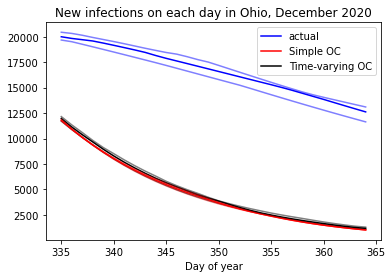

In [645]:
for j in range(3):
    if j == 1:
        plt.plot(days,n[0]*nu_actual_int[:,j], color = 'blue', label = 'actual')
        plt.plot(days,n[0]*nu_opt_int[:,j], color = 'red', label = 'Simple OC')
        plt.plot(days,n[0]*nu_opt_tv_int[:,j], color = 'black', label = 'Time-varying OC')
    else:
        plt.plot(days,n[0]*nu_actual_int[:,j], color = 'blue', alpha = 0.5)
        plt.plot(days,n[0]*nu_opt_int[:,j], color = 'red', alpha = 0.5)   
        plt.plot(days,n[0]*nu_opt_tv_int[:,j], color = 'black', alpha = 0.5)        
    
plt.legend()
plt.xlabel('Day of year')
plt.title('New infections on each day in Ohio, December 2020')

# APMonitor GEKKO OC

In [262]:
# evolve sir model
def sir_additive(gamma,beta0,alpha,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    beta = beta0 * (1 - alpha * np.dot(rho,u))
    for j in range(t-1):
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [263]:
# evolve sir model
def sir_exponential(gamma,beta0,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    beta = beta0 * np.exp(np.dot(rho,u))
    for j in range(t-1):
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [264]:
p = 12

In [265]:
t_d

array([   0,  365,  695, 1037, 1375, 1710])

In [266]:
t_npi

array([   0,  425,  815, 1217, 1615, 2010])

In [267]:
df['sus.365']

draws
0       0.581427
1       0.544107
2       0.580274
3       0.542059
4       0.578013
          ...   
1995    0.545642
1996    0.576818
1997    0.548679
1998    0.583300
1999    0.549972
Name: sus.365, Length: 2000, dtype: float64

In [268]:
t

365

In [269]:
n * [1 for i in range(len(n))]

array([11594163.,  6596855., 38802500., 19893297., 19746227.])

In [270]:
n_samples = 2
n_days = 3
c = (n[0] / 1000000)*np.ones(p)

In [271]:
# calculate cost of policy u
def cost(u_prop):
    nu_cost = 0
    
    for j in range(n_samples):
        _,_, nu = sir_exponential(gamma = df["gamma"][j],
                    beta0 = df["beta0"][j],
                    rho = [df["rho." + str(k+1)][j] for k in range(p)],
                    s0 = df["sus." + str(t)][j],
                    i0 = df["inf." + str(t)][j],
                    t = n_days+1,
                    u = u_prop)
        nu_cost += np.sum(nu)/n_samples
        
    return(nu_cost + n_days*np.dot(c,u_prop))

In [272]:
u_prp = 0.5*np.ones(p)

In [273]:
cost(u_prp)

208.70496029950905

In [274]:
from scipy.optimize import minimize

In [277]:
minimize(cost,u_prp, method = 'L-BFGS-B')

<ipython-input-263-cf3b4c2ff9a4>:8: RuntimeWarning: overflow encountered in double_scalars
  nuj = beta*sj*ij
/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
<ipython-input-263-cf3b4c2ff9a4>:6: RuntimeWarning: overflow encountered in exp
  beta = beta0 * np.exp(np.dot(rho,u))
<ipython-input-263-cf3b4c2ff9a4>:9: RuntimeWarning: invalid value encountered in double_scalars
  sj = sj - nuj
<ipython-input-263-cf3b4c2ff9a4>:10: RuntimeWarning: invalid value encountered in double_scalars
  ij = ij*(1-gamma) + nuj
/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


      fun: nan
 hess_inv: <12x12 LbfgsInvHessProduct with dtype=float64>
      jac: array([34.77737192, 34.77934723, 34.77325361, 34.78703246, 34.78210413,
       34.77831268, 34.78144475, 34.80322715, 34.78128275, 34.78757247,
       34.77506408, 34.76988564])
  message: 'ABNORMAL_TERMINATION_IN_LNSRCH'
     nfev: 273
      nit: 0
     njev: 21
   status: 2
  success: False
        x: array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

## Run model

In [202]:
from gekko import GEKKO

In [256]:
p = 3
n_samples = 100
n_days = 3
c = (n[0] / 1000000)*np.ones(p)

In [257]:
#Initialize Model
m = GEKKO()

#help(m)

#define parameter
eq = m.Param(value=40)

#initialize variables
uopt = m.Array(m.Var,p,value=0.5,lb=0,ub=1)
u1,u2,u3 = uopt                 # rename variables
#u1,u2,u3 = [m.Var() for i in range(3)]

# evolve sir model
def sir_exponential_m(gamma,beta0,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    beta = beta0 * m.exp(np.dot(rho,u))
    for j in range(t-1):
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

# calculate cost of policy u
def cost_m(u_prop):
    nu_cost = 0
    
    for j in range(n_samples):
        _,_, nu = sir_exponential_m(gamma = df["gamma"][j],
                    beta0 = df["beta0"][j],
                    rho = [df["rho." + str(k+1)][j] for k in range(p)],
                    s0 = df["sus." + str(t)][j],
                    i0 = df["inf." + str(t)][j],
                    t = n_days+1,
                    u = u_prop)
        nu_cost += np.sum(nu)/n_samples
        
    return(nu_cost + n_days*np.dot(c,u_prop))

#Objective
m.Obj(cost_m([u1,u2,u3]))
# m.Obj(cost(uopt))

#Set global options
#m.options.IMODE = 3 #steady state optimization

#Solve simulation
m.solve()

apm 195.37.34.66_gk_model13 <br><pre> ----------------------------------------------------------------
 APMonitor, Version 1.0.1
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 @error: Max Equation Length
 Error with line number:           13
 minimize(((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((
 ((((((((((((((((((((((((((((((0+((((((((((0.533662720455173)*(exp(((((-0.634647
 7573088453)*(v1))+((-0.4204016594671796)*(v2)))+((-0.46088983556988894)*(v3))))
 )))*(0.5814267506082098)))*(0.021319139757119975))+((((((0.533662720455173)*(ex
 p(((((-0.6346477573088453)*(v1))+((-0.4204016594671796)*(v2)))+((-0.46088983556
 988894)*(v3)))))))*((0.5814267506082098-((((((0.533662720455173)*(exp(((((-0.63
 46477573088453)*(v1))+((-0.4204016594671796)*(v2)))+((-0.46088983556988894)*(v3
 )))))))*(0.5814267506082098)))*(0.021319139757119975))))))*((0.0178253629514124
 22+((((((0.533662720455173)*(exp(((((-0.634647757308845

Exception:  @error: Max Equation Length
 Error with line number:           13
 minimize(((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((
 ((((((((((((((((((((((((((((((0+((((((((((0.533662720455173)*(exp(((((-0.634647
 7573088453)*(v1))+((-0.4204016594671796)*(v2)))+((-0.46088983556988894)*(v3))))
 )))*(0.5814267506082098)))*(0.021319139757119975))+((((((0.533662720455173)*(ex
 p(((((-0.6346477573088453)*(v1))+((-0.4204016594671796)*(v2)))+((-0.46088983556
 988894)*(v3)))))))*((0.5814267506082098-((((((0.533662720455173)*(exp(((((-0.63
 46477573088453)*(v1))+((-0.4204016594671796)*(v2)))+((-0.46088983556988894)*(v3
 )))))))*(0.5814267506082098)))*(0.021319139757119975))))))*((0.0178253629514124
 22+((((((0.533662720455173)*(exp(((((-0.6346477573088453)*(v1))+((-0.4204016594
 671796)*(v2)))+((-0.46088983556988894)*(v3)))))))*(0.5814267506082098)))*(0.021
 319139757119975))))))+((((((0.533662720455173)*(exp(((((-0.6346477573088453)*(v
 1))+((-0.4204016594671796)*(v2

In [249]:
uopt

array([[1.7394425536e-08], [1.8084670406e-08], [1.4971969699e-08]],
      dtype=object)

In [250]:
u_prop = np.array([uopt[j][0] for j in range(p)]); u_prop

array([1.73944255e-08, 1.80846704e-08, 1.49719697e-08])

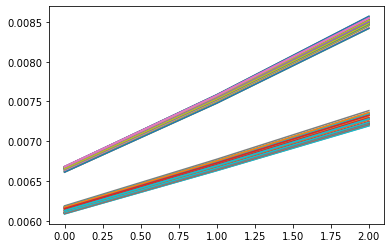

In [255]:
for j in range(100):
    s,i,nu = sir_exponential(gamma = df["gamma"][j],
                    beta0 = df["beta0"][j],
                    rho = [df["rho." + str(k+1)][j] for k in range(p)],
                    s0 = df["sus." + str(t)][j],
                    i0 = df["inf." + str(t)][j],
                    t = n_days+1,
                    u = uopt)
    plt.plot(range(n_days),nu)

In [ ]:
#Initialize Model
m = GEKKO()

#help(m)

#define parameter
eq = m.Param(value=40)

#initialize variables
x1,x2,x3,x4 = [m.Var() for i in range(4)]

#initial values
x1.value = 1
x2.value = 5
x3.value = 5
x4.value = 1

# lower bounds
x1.lower = 1
x2.lower = 1
x3.lower = 1
x4.lower = 1

# upper bounds
x1.upper = 5
x2.upper = 5
x3.upper = 5
x4.upper = 5

#Equations
m.Equation(x1*x2*x3*x4>=25)
m.Equation(x1**2+x2**2+x3**2+x4**2==eq)

#Objective
m.Obj(x1*x4*(x1+x2+x3)+x3)

#Set global options
m.options.IMODE = 3 #steady state optimization

#Solve simulation
m.solve()

#Results
print('')
print('Results')
print('x1: ' + str(x1.value))
print('x2: ' + str(x2.value))
print('x3: ' + str(x3.value))
print('x4: ' + str(x4.value))

In [ ]:
# create GEKKO model
m = GEKKO()
# time points
t=30
m.time = np.linspace(1,t,t)
# constants
E,c,r,k,U_max = 1,17.5,0.71,80.5,20
# fishing rate
u = m.MV(value=0.5,lb=0,ub=1)
u.STATUS = 1
u.DCOST = 0
x = m.Var(value=70) # fish population
# fish population balance
m.Equation(x.dt() == r*x*(1-x/k)-u*U_max)
J = m.Var(value=0) # objective (profit)
Jf = m.FV() # final objective
Jf.STATUS = 1
m.Connection(Jf,J,pos2='end')
m.Equation(J.dt() == (E-c/x)*u*U_max)
m.Obj(-Jf) # maximize profit

Optimal Profit: 106.90608335


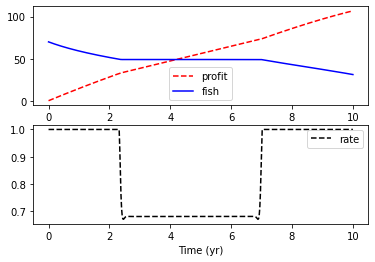

In [90]:
m.options.IMODE = 6  # optimal control
m.options.NODES = 3  # collocation nodes
m.options.SOLVER = 3 # solver (IPOPT)
m.solve(disp=False) # Solve
print('Optimal Profit: ' + str(Jf.value[0]))
plt.figure(1) # plot results
plt.subplot(2,1,1)
plt.plot(m.time,J.value,'r--',label='profit')
plt.plot(m.time,x.value,'b-',label='fish')
plt.legend()
plt.subplot(2,1,2)
plt.plot(m.time,u.value,'k--',label='rate')
plt.xlabel('Time (yr)')
plt.legend()
plt.show()

# Plot NPIs over time

In [142]:
ts = t_npi
X = u

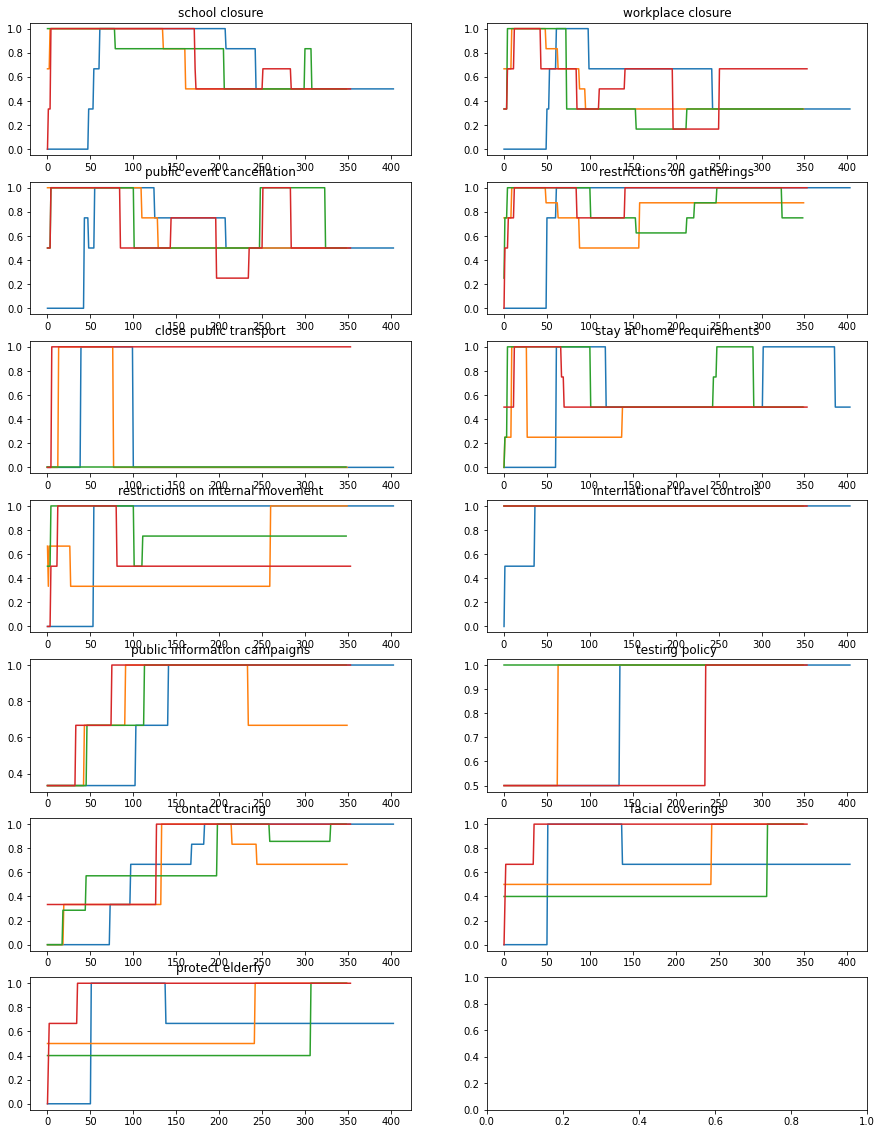

In [143]:
fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(15,20))

for j in range(s):
    axs[0,0].plot(X[ts[j]:ts[j+1],0])
    axs[0,0].set_title("school closure")
    
for j in range(s):
    axs[0,1].plot(X[ts[j]:ts[j+1],1])
    axs[0,1].set_title("workplace closure")
    
for j in range(s):
    axs[1,0].plot(X[ts[j]:ts[j+1],2])
    axs[1,0].set_title("public event cancellation")
    
for j in range(s):
    axs[1,1].plot(X[ts[j]:ts[j+1],3])
    axs[1,1].set_title("restrictions on gatherings")
    
for j in range(s):
    axs[2,0].plot(X[ts[j]:ts[j+1],4])
    axs[2,0].set_title("close public transport")   

for j in range(s):
    axs[2,1].plot(X[ts[j]:ts[j+1],5])
    axs[2,1].set_title("stay at home requirements")
    
for j in range(s):
    axs[3,0].plot(X[ts[j]:ts[j+1],6])
    axs[3,0].set_title("restrictions on internal movement")   

for j in range(s):
    axs[3,1].plot(X[ts[j]:ts[j+1],7])
    axs[3,1].set_title("international travel controls")  

for j in range(s):
    axs[4,0].plot(X[ts[j]:ts[j+1],8])
    axs[4,0].set_title("public information campaigns")   

for j in range(s):
    axs[4,1].plot(X[ts[j]:ts[j+1],9])
    axs[4,1].set_title("testing policy")  

for j in range(s):
    axs[5,0].plot(X[ts[j]:ts[j+1],10])
    axs[5,0].set_title("contact tracing")   

for j in range(s):
    axs[5,1].plot(X[ts[j]:ts[j+1],11])
    axs[5,1].set_title("facial coverings")  
    
for j in range(s):
    axs[6,0].plot(X[ts[j]:ts[j+1],11])
    axs[6,0].set_title("protect elderly") 
    
#plt.savefig("npi_variation.pdf")

## covidest stan model code

In [ ]:
"""
data {
  int<lower=0> cutoff;
  int<lower=1> n_days;
  int<lower=1> days[n_days];
  int<lower=1> n_d_days;
  int<lower=1> d_days[n_d_days];
  real<lower=0> N;      // population
  int<lower=0> d[n_d_days];              // deaths
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution
  real<lower=0> ifr_min;
  real<lower=0> ifr_max;
  
  int<lower=1> n_v; // number of viral tests administered
  int<lower=1> n_s; // number of serology tests administered
  real<lower=0, upper=1> vp_hat;  // viral prevalence
  real<lower=0, upper=1> sp_hat; //seroprevalence
  int T1;  // start of phase 1 testing
  int T2;  // end of phase 1 testing
  
  int<lower=0> n_per;
  int<lower=0> n_test_days;
  int<lower=0> test_days[n_test_days];
  vector<lower=0>[n_per] cc;
  vector<lower=0>[n_per+1] tests;
  int<lower=0> per_ends[n_per+1];
}
parameters {
  real<lower=5.5, upper = 11.5> gamma_inv;
  real<lower=0> beta[n_days];
  real sigma_tilde;
  real<lower=ifr_min,upper=ifr_max> ifr;
  real y0_tilde[2];
  real<lower = 0,upper=2> phi;
  real<lower = 0> sigma_phi;
}
transformed parameters{
  matrix<lower=0>[n_days+1, 3] y;
  vector<lower=0>[n_days] nu;
  real<lower=0,upper=1> sigma = Phi(sigma_tilde);
  real<lower=0, upper=1> vp;
  real<lower=0,upper=1> sp;
  real<lower=0> vp_se;
  real<lower=0> sp_se;
  real<lower=1.0/11.5,upper=1.0/5.5> gamma = 1/gamma_inv;
  real<lower=0> death_par[n_days];
  vector<lower=0>[n_per] cc_mean;
  vector<lower=0>[n_per] cc_sd;
  {
    y[1,1] = N*0.99 + 0.01*N*Phi(y0_tilde[1]);
    y[1,2] = 0.01*N*(1-Phi(y0_tilde[1]))*Phi(y0_tilde[2]);
    y[1,3] = N - y[1,1] - y[1,2];
    for(t in 1:n_days){
      y[t+1,1] = y[t,1] * (1 - beta[t] * y[t,2] / N);
      y[t+1,2] = y[t,2] * (1 + beta[t] * y[t,1] / N - gamma);
      y[t+1,3] = y[t,3] + gamma * y[t,2];
      nu[t] = y[t,1] - y[t+1,1];
      if(t <= cutoff){
      death_par[t]=ifr*sum(tau_rev[(cutoff-t+2):(cutoff+1)] .*nu[1:t])+ifr*sum(tau_rev[1:(cutoff-t+1)])*(y[1,2]+y[1,3]);
      }else{
      death_par[t]=ifr*sum(tau_rev .*nu[(t-cutoff):t]);
      }
    }
  }
  
  for(t in 1:n_per){
    cc_mean[t] = phi*(sqrt(sum(tests[1:(t+1)])/N) * (N-y[per_ends[t+1]+1,1]) - sqrt(sum(tests[1:t])/N) * (N-y[per_ends[t]+1,1]));
    cc_sd[t] = sigma_phi * sqrt(tests[t+1]/N);
  }

  vp = mean(y[(T1+1):(T2+1),2])/N;
  vp_se = sqrt(vp*(1-vp)/n_v);
  
  sp = mean(y[(T1+1):(T2+1),3])/N;
  sp_se = sqrt(sp*(1-sp)/n_s);
}
model {
  //priors
  beta[1] ~ uniform(0,1);
  beta[2:n_days] ~ normal(beta[1:(n_days-1)], sigma);
  gamma_inv ~ normal(8.5, 1.5) T[5.5,11.5];
  sigma_tilde ~ normal(0,1);
  ifr ~ uniform(ifr_min,ifr_max);
  y0_tilde ~ normal(0,1);
  phi ~ uniform(0,2);
  sigma_phi ~ uniform(0,3);
  
  //likelihoods
  d ~ poisson(death_par[1:n_d_days]);
  vp_hat ~ normal(vp,vp_se) T[0,1];
  sp_hat ~ normal(sp,sp_se) T[0,1];
  100*cc/N ~ normal(100/N * cc_mean, cc_sd);
}"""